# LD7186 – Big Data Analytics
## Accidental Drug-Related Deaths in Connecticut (2012–2024)


**Dataset:** Accidental_Drug_Related_Deaths_2012-2024.csv  
**Source:** Office of the Chief Medical Examiner, Connecticut  
**Rows:** 12,963 | **Columns:** 48

---
## TASK 1 – Data Exploration, Research Questions & Hypothesis

### 1.1 – Import Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Global style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titleweight': 'bold'
})

print('All libraries imported successfully.')

All libraries imported successfully.


### 1.2 – Load Dataset

In [26]:
# ── Update this path if running locally ──────────────────────────────────────
FILE_PATH = '/content/sample_data/Accidental_Drug_Related_Deaths_2012-2024.csv'
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(FILE_PATH)

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
df.head(3)

Dataset shape: 12,963 rows × 48 columns



,Date,Date Type,Age,Sex,Race,Ethnicity,Residence City,Residence County,Residence State,Injury City,...,Xylazine,Gabapentin,Opiate NOS,Heroin/Morph/Codeine,Other Opioid,Any Opioid,Other,ResidenceCityGeo,InjuryCityGeo,DeathCityGeo
0,01/02/2023,Date of death,65.0,Male,White,"No, not Spanish/Hispanic/Latino",BRIDGEPORT,FAIRFIELD,CT,BRIDGEPORT,...,NaN,NaN,NaN,NaN,NaN,Y,NaN,"BRIDGEPORT, CT\n(41.179195, -73.189476)","BRIDGEPORT, CT\n(41.179195, -73.189476)","CT\n(41.57350273, -72.738305908)"
1,01/18/2023,Date of death,42.0,Male,White,"No, not Spanish/Hispanic/Latino",WATERBURY,NEW HAVEN,CT,FARMINGTON,...,NaN,NaN,NaN,NaN,NaN,Y,NaN,"WATERBURY, CT\n(41.5542609, -73.0430692)","FARMINGTON, CT\n(41.726536, -72.8250564)","CT\n(41.57350273, -72.738305908)"
2,01/26/2022,Date of death,34.0,Male,White,NaN,BROOKFIELD,FAIRFIELD,CT,BROOKFIELD,...,Y,NaN,NaN,Y,NaN,Y,NaN,"BROOKFIELD, CT\n(41.46736000000004, -73.398259...","BROOKFIELD, CT\n(41.46736000000004, -73.398259...","CT\n(41.57350273000003, -72.73830590799997)"


### 1.3 – Data Types & Initial Inspection

In [27]:
print('─── Column Data Types ───────────────────────────────────')
print(df.dtypes)
print()
print('─── Basic Info ─────────────────────────────────────────')
df.info()

─── Column Data Types ───────────────────────────────────
Date                              object
Date Type                         object
Age                              float64
Sex                               object
Race                              object
Ethnicity                         object
Residence City                    object
Residence County                  object
Residence State                   object
Injury City                       object
Injury County                     object
Injury State                      object
Injury Place                      object
Description of Injury             object
Death City                        object
Death County                      object
Death State                       object
Location                          object
Location if Other                 object
Cause of Death                    object
Manner of Death                   object
Other Significant Conditions      object
Heroin                            object

### 1.4 – Missing Value Analysis

In [28]:
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(1)
null_summary = pd.DataFrame({'Missing Count': null_counts,
                              'Missing %': null_pct})
null_summary = null_summary[null_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Columns with missing values: {len(null_summary)}')
print()
print(null_summary.to_string())

Columns with missing values: 45

                               Missing Count  Missing %
Morphine (Not Heroin)                  12901       99.5
Hydromorphone                          12883       99.4
Opiate NOS                             12835       99.0
Meth/Amphetamine                       12836       99.0
Oxymorphone                            12788       98.7
Hydrocodone                            12790       98.7
Tramad                                 12653       97.6
Other Opioid                           12650       97.6
Amphet                                 12468       96.2
Gabapentin                             12408       95.7
Heroin death certificate (DC)          12223       94.3
Other                                  12086       93.2
Fentanyl Analogue                      11942       92.1
Oxycodone                              11893       91.7
Methadone                              11772       90.8
Location if Other                      11769       90.8
Other Significa

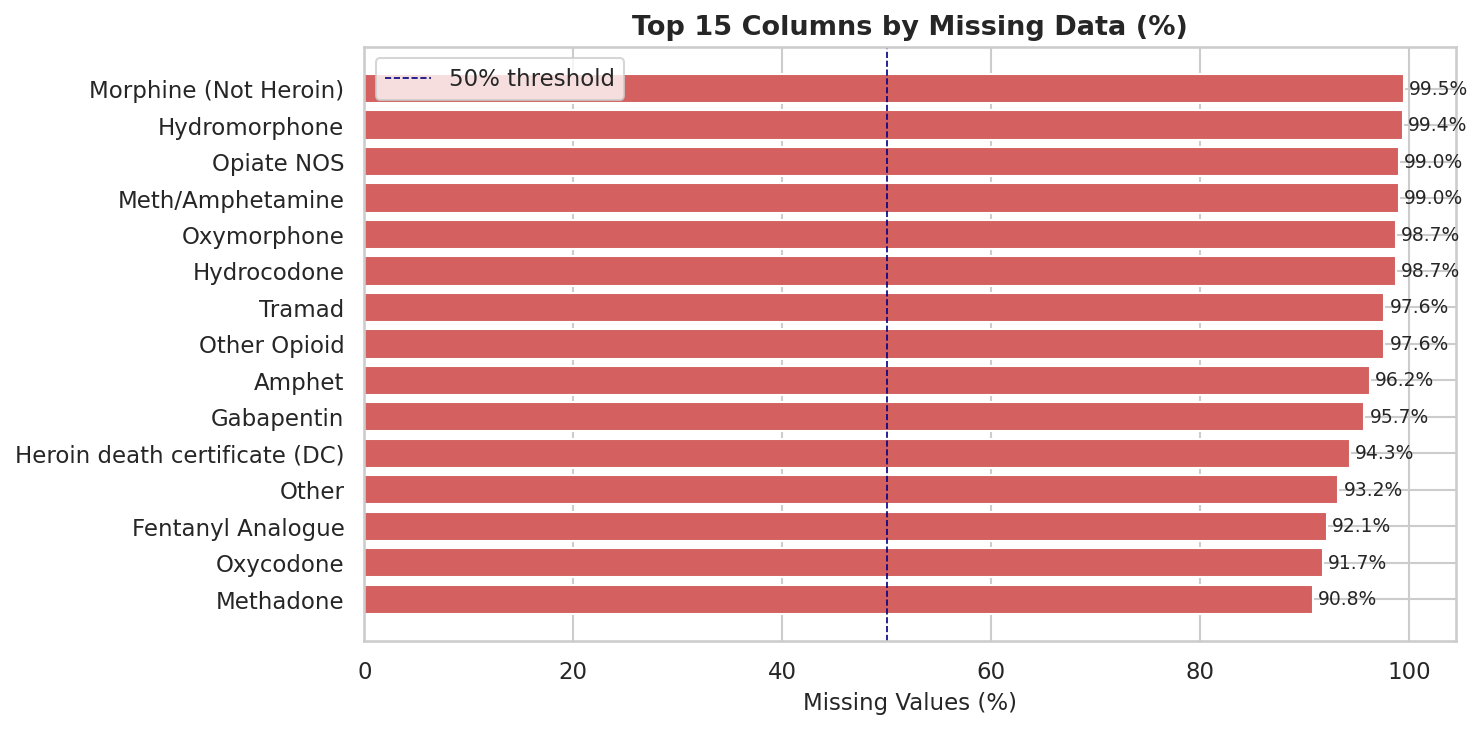

Screenshot this output for the report.


In [29]:
# Visualise missing values (top 15 columns)
top15 = null_summary.head(15)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top15.index[::-1], top15['Missing %'][::-1], color='#D46060', edgecolor='white')
ax.set_xlabel('Missing Values (%)')
ax.set_title('Top 15 Columns by Missing Data (%)')
ax.axvline(50, color='navy', linestyle='--', linewidth=0.8, label='50% threshold')
ax.legend()
for bar, val in zip(bars, top15['Missing %'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('Screenshot this output for the report.')

### 1.5 – EDA Visualisation 1: Age Distribution

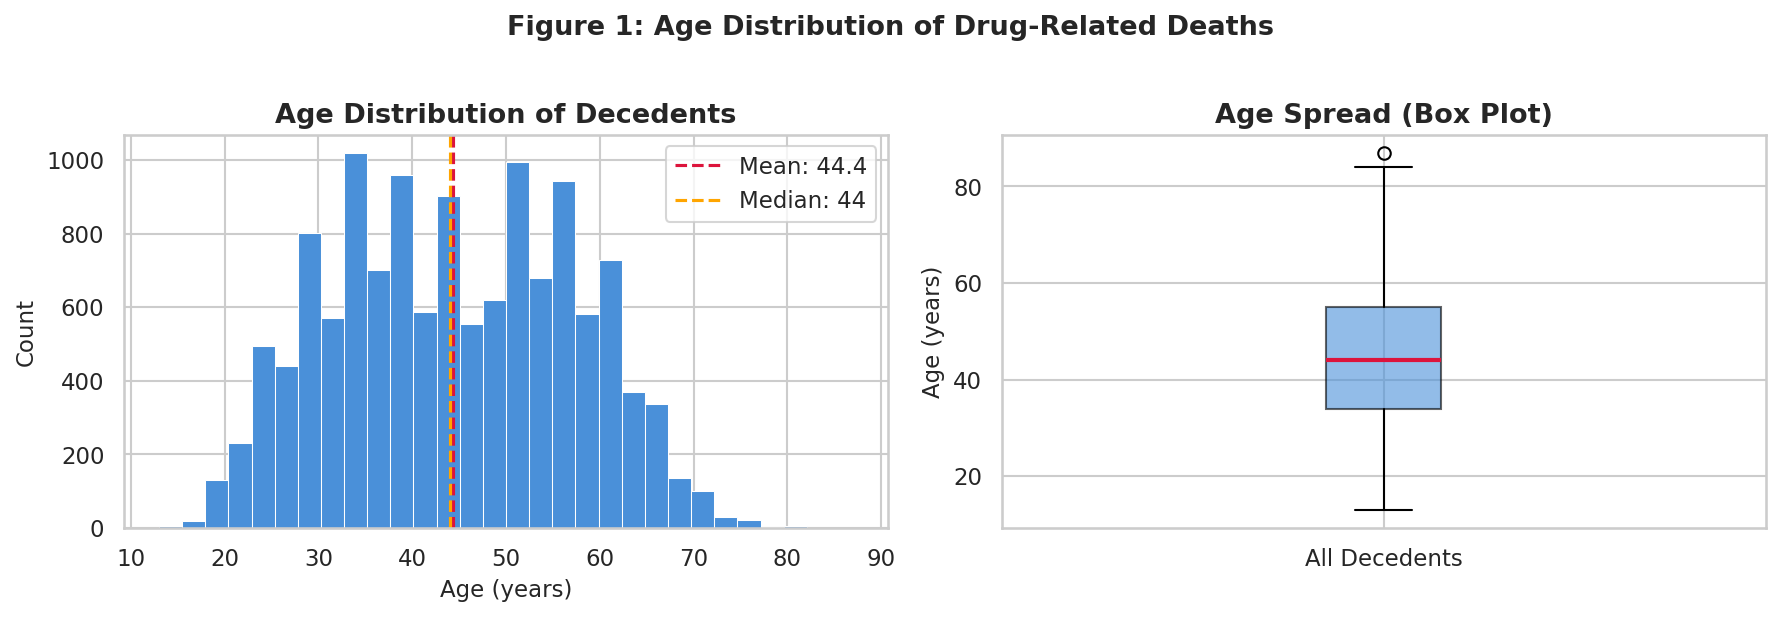

Age Stats:
count    12961.0
mean        44.4
std         12.7
min         13.0
25%         34.0
50%         44.0
75%         55.0
max         87.0
Name: Age, dtype: float64


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['Age'].dropna(), bins=30, color='#4A90D9', edgecolor='white', linewidth=0.5)
axes[0].set_title('Age Distribution of Decedents')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['Age'].mean(), color='crimson', linestyle='--',
                label=f"Mean: {df['Age'].mean():.1f}")
axes[0].axvline(df['Age'].median(), color='orange', linestyle='--',
                label=f"Median: {df['Age'].median():.0f}")
axes[0].legend()

# Box plot
axes[1].boxplot(df['Age'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#4A90D9', alpha=0.6),
                medianprops=dict(color='crimson', linewidth=2))
axes[1].set_title('Age Spread (Box Plot)')
axes[1].set_ylabel('Age (years)')
axes[1].set_xticklabels(['All Decedents'])

plt.suptitle('Figure 1: Age Distribution of Drug-Related Deaths', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Age Stats:\n{df['Age'].describe().round(1)}")

### 1.6 – EDA Visualisation 2: Deaths by Sex

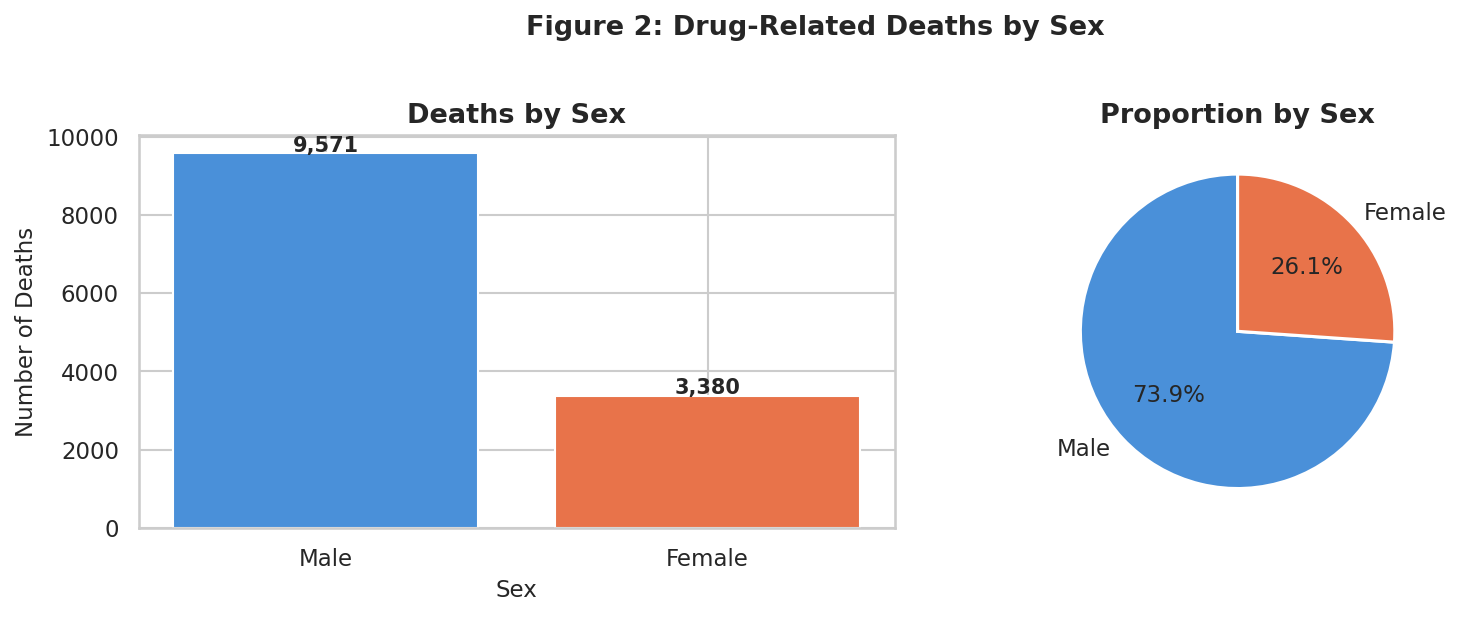

In [31]:
sex_counts = df['Sex'].value_counts().drop(['Unknown', 'X'], errors='ignore')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors_sex = ['#4A90D9', '#E8734A', '#6ABF69']
axes[0].bar(sex_counts.index, sex_counts.values, color=colors_sex, edgecolor='white')
axes[0].set_title('Deaths by Sex')
axes[0].set_ylabel('Number of Deaths')
axes[0].set_xlabel('Sex')
for i, (cat, val) in enumerate(zip(sex_counts.index, sex_counts.values)):
    axes[0].text(i, val + 40, f'{val:,}', ha='center', fontsize=10, fontweight='bold')

axes[1].pie(sex_counts.values, labels=sex_counts.index, autopct='%1.1f%%',
            colors=colors_sex, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proportion by Sex')

plt.suptitle('Figure 2: Drug-Related Deaths by Sex', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_deaths_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.7 – EDA Visualisation 3: Deaths by Race

=== Figure 1: Overall Race Counts ===
Race_Clean
White                     10805
Black/African American     1836
Other                        98
Unknown                      63
Asian/Indian                 36
Asian, Other                 24

=== Figure 2: City-Level Counts ===
Race_Clean   White  Black/African American  Other/Unknown
Death City                                               
Hartford       812                     239             27
New Haven      532                     218             11
Waterbury      613                     101             12
Bridgeport     463                     149             11
New Britain    323                      28              8


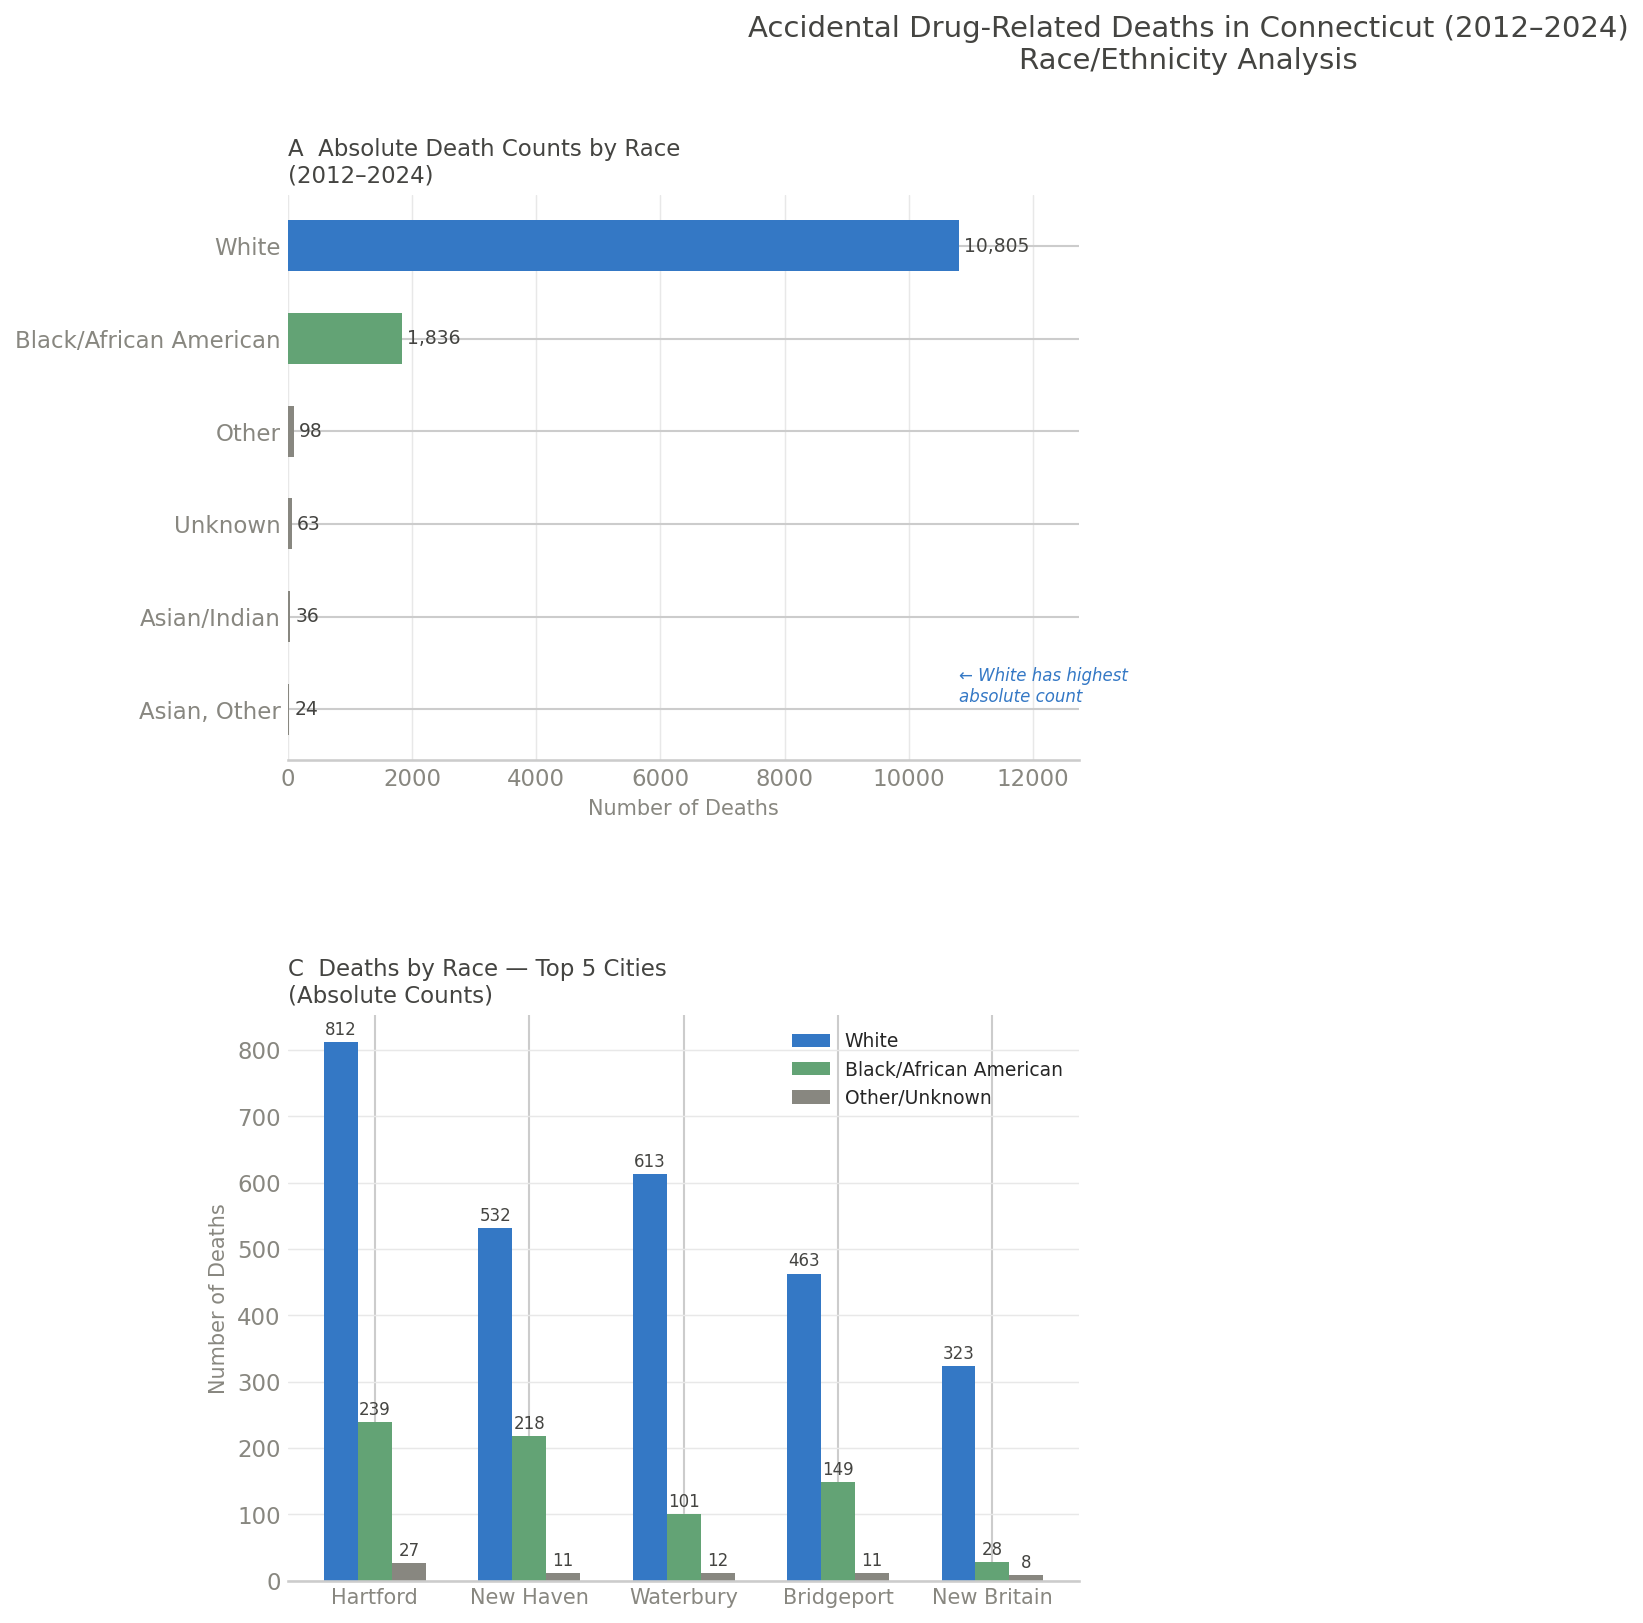

In [32]:
df['Race_Clean'] = df['Race'].str.strip().str.title().replace({
    'Black Or African American': 'Black/African American',
    'Black':                     'Black/African American',
    'Other (Specify)':           'Other',
    'Other Asian (Specify)':     'Other Asian',
    'Asian Indian':              'Asian/Indian',
})
df['Death City'] = df['Death City'].str.strip().str.title()

# ── Overall race counts ────────────────────────────────────────────────────
race_counts = df['Race_Clean'].value_counts().head(6)
print("=== Figure 1: Overall Race Counts ===")
print(race_counts.to_string())

# ── Top-5 city breakdown ───────────────────────────────────────────────────
top3      = ['Hartford', 'New Haven', 'Waterbury', 'Bridgeport', 'New Britain']  # ← changed to top 5
df3       = df[df['Death City'].isin(top3)].copy()
pivot     = df3.groupby(['Death City', 'Race_Clean']).size().unstack(fill_value=0)
pivot['Other/Unknown'] = pivot.drop(
    columns=['White', 'Black/African American'], errors='ignore'
).sum(axis=1)
city_data = pivot[['White', 'Black/African American', 'Other/Unknown']].loc[top3]

print("\n=== Figure 2: City-Level Counts ===")
print(city_data.to_string())

# ── Plot ───────────────────────────────────────────────────────────────────
BLUE   = '#3478C5'
GREEN  = '#63A375'
GRAY   = '#888780'
AMBER  = '#E8A838'
TEXT   = '#444441'
MUTED  = '#888780'
GRID   = '#e8e8e8'

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('white')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
top6_labels = race_counts.index.tolist()[::-1]
top6_vals   = race_counts.values.tolist()[::-1]
bar_colors  = [BLUE if l == 'White' else
               GREEN if l == 'Black/African American' else
               GRAY  for l in top6_labels]
bars = ax1.barh(top6_labels, top6_vals, color=bar_colors,
                edgecolor='none', height=0.55)
for bar, val in zip(bars, top6_vals):
    ax1.text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=9, color=TEXT)
ax1.set_xlabel('Number of Deaths', fontsize=10, color=MUTED)
ax1.set_title('A  Absolute Death Counts by Race\n(2012–2024)', fontsize=11,
              fontweight='normal', color=TEXT, loc='left')
ax1.xaxis.grid(True, color=GRID, linewidth=0.7)
ax1.set_axisbelow(True)
for sp in ['top', 'right', 'left']:
    ax1.spines[sp].set_visible(False)
ax1.spines['bottom'].set_color('#cccccc')
ax1.tick_params(colors=MUTED, length=0)
ax1.set_xlim(0, max(top6_vals) * 1.18)
ax1.annotate('← White has highest\nabsolute count', xy=(10805, 0.08),
             fontsize=8, color=BLUE, style='italic')

ax3 = fig.add_subplot(gs[1, 0])
x     = np.arange(len(top3))
w     = 0.22                          # ← slightly narrower to fit 5 cities
cols3 = [BLUE, GREEN, GRAY]
grps  = ['White', 'Black/African American', 'Other/Unknown']
for i, (col, grp) in enumerate(zip(cols3, grps)):
    bars3 = ax3.bar(x + i * w, city_data[grp], w, label=grp,
                    color=col, edgecolor='none')
    for bar in bars3:
        h = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width() / 2, h + 5,
                 f'{int(h):,}', ha='center', va='bottom',
                 fontsize=8, color=TEXT)
ax3.set_xticks(x + w)
ax3.set_xticklabels(top3, fontsize=10)  # ← slightly smaller font for 5 labels
ax3.set_ylabel('Number of Deaths', fontsize=10, color=MUTED)
ax3.set_title('C  Deaths by Race — Top 5 Cities\n(Absolute Counts)',  # ← updated label
              fontsize=11, fontweight='normal', color=TEXT, loc='left')
ax3.yaxis.grid(True, color=GRID, linewidth=0.7)
ax3.set_axisbelow(True)
for sp in ['top', 'right', 'left']:
    ax3.spines[sp].set_visible(False)
ax3.spines['bottom'].set_color('#cccccc')
ax3.tick_params(colors=MUTED, length=0)
ax3.legend(fontsize=9, frameon=False, loc='upper right')

# ── Shared caption ────────────────────────────────────────────────────────────

fig.suptitle('Accidental Drug-Related Deaths in Connecticut (2012–2024)\nRace/Ethnicity Analysis',
             fontsize=14, fontweight='normal', color=TEXT, y=0.98)

plt.savefig('fig3_death_by_race.png', dpi=150, bbox_inches='tight',
            facecolor='white')

### 1.8 – EDA Visualisation 4: Deaths Per Year (Trend)

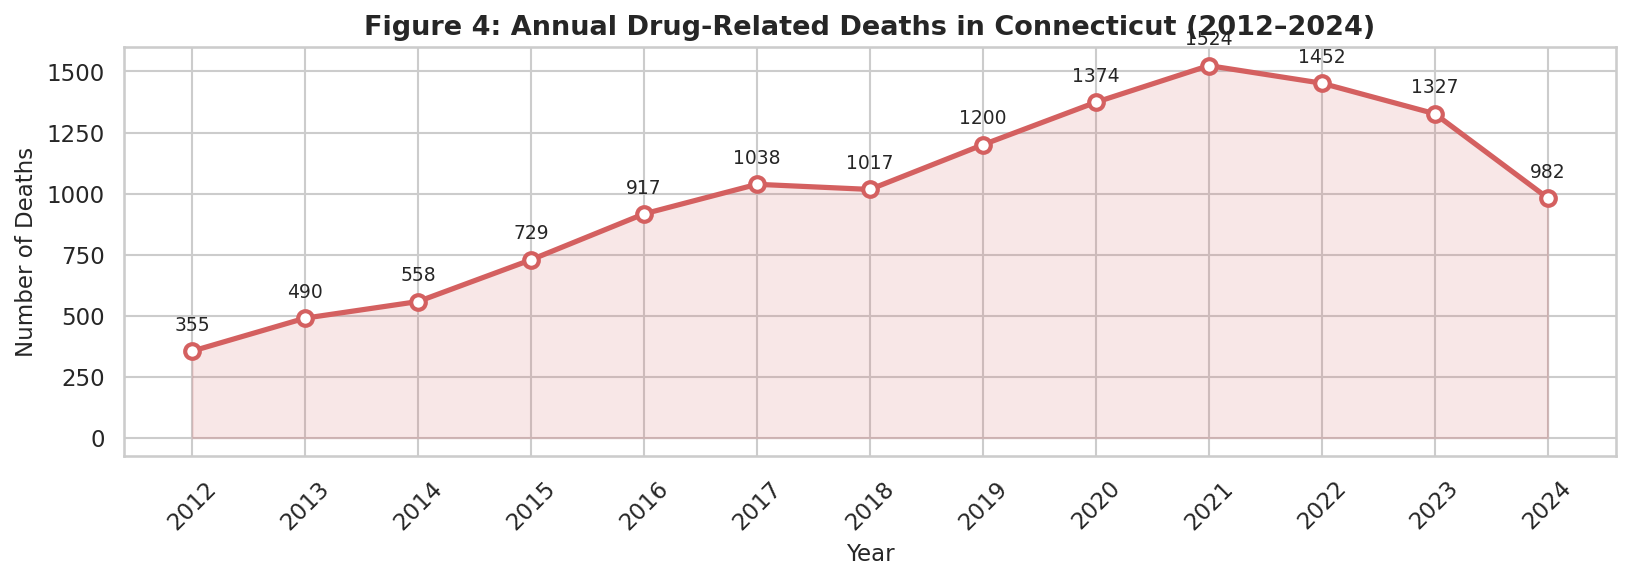

 Year  Deaths
 2012     355
 2013     490
 2014     558
 2015     729
 2016     917
 2017    1038
 2018    1017
 2019    1200
 2020    1374
 2021    1524
 2022    1452
 2023    1327
 2024     982


In [33]:
df['Date_parsed'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', errors='coerce')
df['Year'] = df['Date_parsed'].dt.year

yearly = df.groupby('Year').size().reset_index(name='Deaths')
yearly = yearly[(yearly['Year'] >= 2012) & (yearly['Year'] <= 2024)]

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(yearly['Year'], yearly['Deaths'], alpha=0.15, color='#D46060')
ax.plot(yearly['Year'], yearly['Deaths'], 'o-', color='#D46060', linewidth=2.5,
        markersize=7, markerfacecolor='white', markeredgewidth=2)
for _, row in yearly.iterrows():
    ax.annotate(f"{int(row['Deaths'])}",
                xy=(row['Year'], row['Deaths']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9)
ax.set_xticks(yearly['Year'])
ax.set_xticklabels(yearly['Year'].astype(int), rotation=45)
ax.set_ylabel('Number of Deaths')
ax.set_xlabel('Year')
ax.set_title('Figure 4: Annual Drug-Related Deaths in Connecticut (2012–2024)')
plt.tight_layout()
plt.savefig('fig4_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(yearly.to_string(index=False))

### 1.9 – EDA Visualisation 5: Substance Involvement Frequency

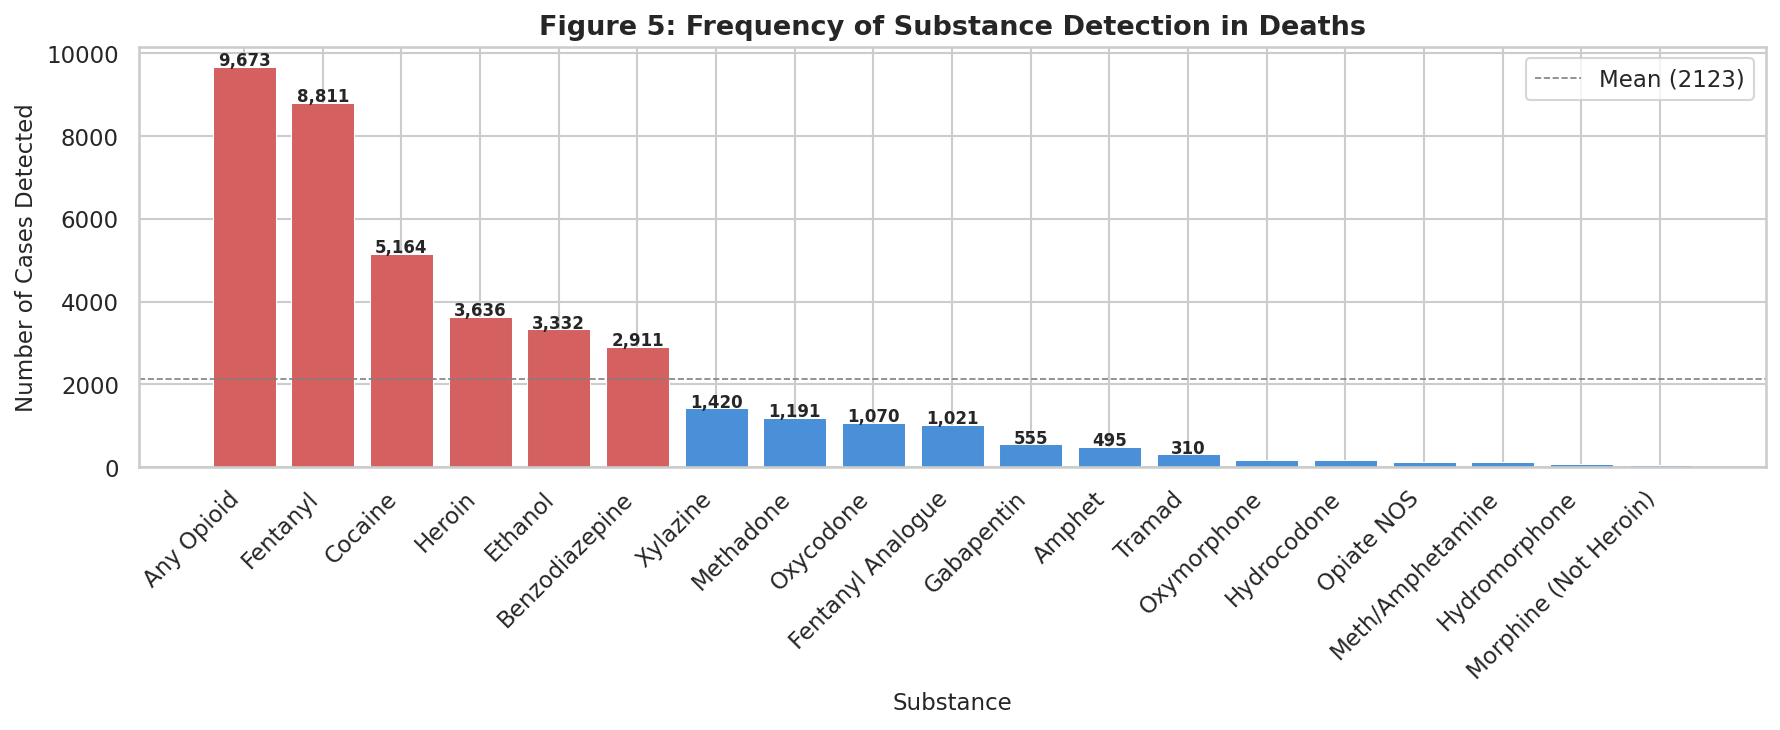

In [34]:
# Define all substance columns
SUBSTANCE_COLS = [
    'Heroin', 'Cocaine', 'Fentanyl', 'Fentanyl Analogue',
    'Oxycodone', 'Oxymorphone', 'Ethanol', 'Hydrocodone',
    'Benzodiazepine', 'Methadone', 'Meth/Amphetamine', 'Amphet',
    'Tramad', 'Hydromorphone', 'Morphine (Not Heroin)',
    'Xylazine', 'Gabapentin', 'Opiate NOS', 'Any Opioid'
]

# Binary encode: any non-null value that starts with 'Y' or 'y' = 1
def encode_substance(series):
    return series.astype(str).str.strip().str.upper().str.startswith('Y').astype(int)

for col in SUBSTANCE_COLS:
    if col in df.columns:
        df[col + '_flag'] = encode_substance(df[col])

flag_cols = [c + '_flag' for c in SUBSTANCE_COLS if c in df.columns]
substance_sums = df[flag_cols].sum().sort_values(ascending=False)
substance_sums.index = [c.replace('_flag', '') for c in substance_sums.index]

fig, ax = plt.subplots(figsize=(12, 5))
colors_sub = ['#D46060' if v > substance_sums.mean() else '#4A90D9'
              for v in substance_sums.values]
bars = ax.bar(substance_sums.index, substance_sums.values,
              color=colors_sub, edgecolor='white', linewidth=0.5)
ax.axhline(substance_sums.mean(), color='gray', linestyle='--', linewidth=0.8,
           label=f'Mean ({substance_sums.mean():.0f})')
ax.set_xlabel('Substance')
ax.set_ylabel('Number of Cases Detected')
ax.set_title('Figure 5: Frequency of Substance Detection in Deaths')
ax.set_xticklabels(substance_sums.index, rotation=45, ha='right')
ax.legend()
for bar, val in zip(bars, substance_sums.values):
    if val > 200:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{val:,}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_substance_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.10 – Research Questions & Hypothesis Statement

In [35]:
print("""
════════════════════════════════════════════════════════════════════════
 RESEARCH QUESTIONS
════════════════════════════════════════════════════════════════════════

 RQ1: How has fentanyl involvement in accidental drug-related deaths
      changed in Connecticut between 2012 and 2024?

 RQ2: Does the mean age at death differ significantly across
      different primary substance groups (Heroin, Fentanyl, Cocaine,
      Benzodiazepine, Ethanol)?

 RQ3: Is there a sex-based difference in the rate of polydrug
      (multiple substances simultaneously) deaths?

 RQ4: Which cities/locations have the highest concentration of
      accidental drug-related deaths in Connecticut?

════════════════════════════════════════════════════════════════════════
 HYPOTHESIS (for RQ2)
════════════════════════════════════════════════════════════════════════

 H₀ (Null):        The mean age at death does NOT differ significantly
                   across substance groups.
                   μ_heroin = μ_fentanyl = μ_cocaine = μ_benzo = μ_ethanol

 H₁ (Alternative): The mean age at death DOES differ significantly
                   across at least one substance group.
                   At least one μᵢ ≠ μⱼ

 Test:             One-Way Analysis of Variance (ANOVA)
 Significance:     α = 0.05
 Decision rule:    Reject H₀ if p-value < 0.05
════════════════════════════════════════════════════════════════════════
""")


════════════════════════════════════════════════════════════════════════
 RESEARCH QUESTIONS
════════════════════════════════════════════════════════════════════════

 RQ1: How has fentanyl involvement in accidental drug-related deaths
      changed in Connecticut between 2012 and 2024?

 RQ2: Does the mean age at death differ significantly across
      different primary substance groups (Heroin, Fentanyl, Cocaine,
      Benzodiazepine, Ethanol)?

 RQ3: Is there a sex-based difference in the rate of polydrug
      (multiple substances simultaneously) deaths?

 RQ4: Which cities/locations have the highest concentration of
      accidental drug-related deaths in Connecticut?

════════════════════════════════════════════════════════════════════════
 HYPOTHESIS (for RQ2)
════════════════════════════════════════════════════════════════════════

 H₀ (Null):        The mean age at death does NOT differ significantly
                   across substance groups.
                   μ_heroin = μ_

---
## TASK 2 – Solution Exploration

### 2.1 – Workflow Diagram

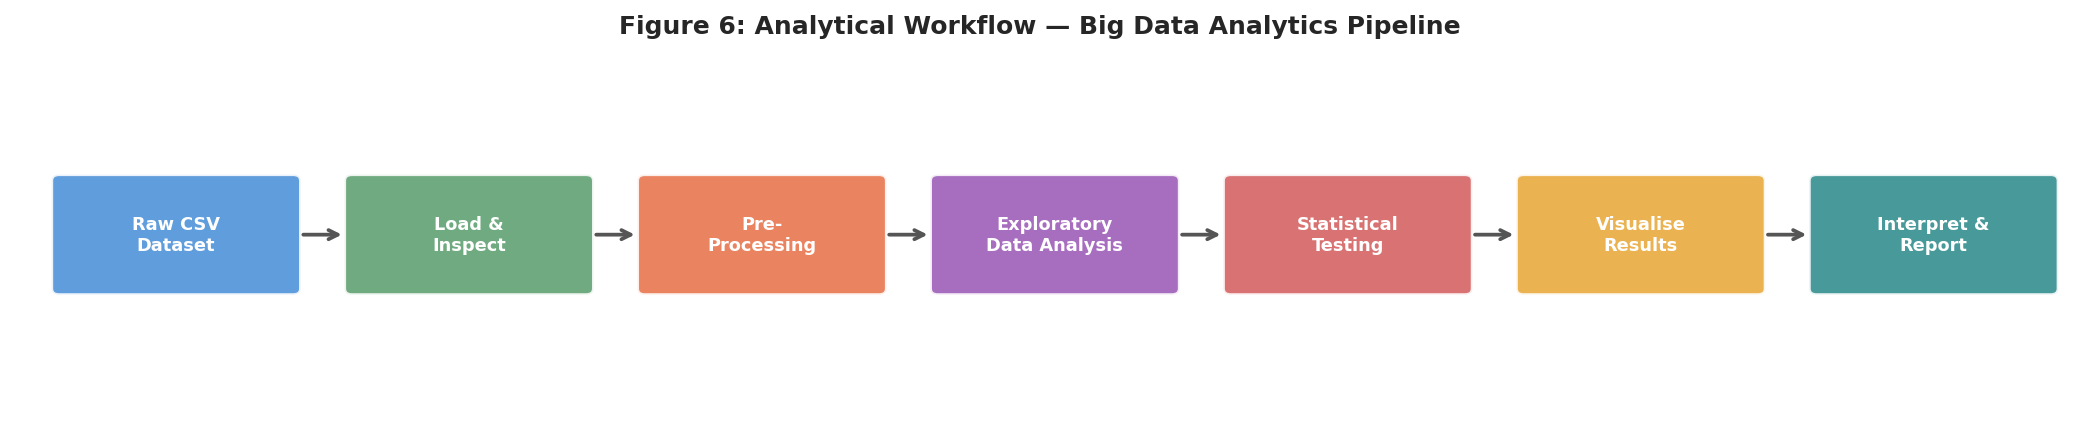

In [37]:
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(14, 3))
ax.set_xlim(0, 14)
ax.set_ylim(0, 3)
ax.axis('off')

steps = [
    ('Raw CSV\nDataset',      '#4A90D9'),
    ('Load &\nInspect',       '#5B9E6E'),
    ('Pre-\nProcessing',      '#E8734A'),
    ('Exploratory\nData Analysis', '#9B59B6'),
    ('Statistical\nTesting',  '#D46060'),
    ('Visualise\nResults',    '#E8A838'),
    ('Interpret &\nReport',   '#2E8B8B'),
]

box_w, box_h = 1.6, 0.9
y_center = 1.5
start_x = 0.3
gap = 0.4

for i, (label, color) in enumerate(steps):
    x = start_x + i * (box_w + gap)
    rect = mpatches.FancyBboxPatch(
        (x, y_center - box_h/2), box_w, box_h,
        boxstyle='round,pad=0.05',
        facecolor=color, edgecolor='white', linewidth=1.5, alpha=0.88
    )
    ax.add_patch(rect)
    ax.text(x + box_w/2, y_center, label,
            ha='center', va='center', fontsize=8.5,
            fontweight='bold', color='white',
            multialignment='center')
    if i < len(steps) - 1:
        arrow_x = x + box_w + 0.04
        ax.annotate('', xy=(arrow_x + gap - 0.08, y_center),
                    xytext=(arrow_x, y_center),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=1.8))

ax.set_title('Figure 6: Analytical Workflow — Big Data Analytics Pipeline',
             fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('fig6_workflow_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 – Technology Comparison Summary

In [38]:
comparison = pd.DataFrame({
    'Approach': ['Descriptive Statistics', 'Inferential Statistics', 'Machine Learning (Clustering)'],
    'Tools': ['pandas, NumPy, seaborn', 'scipy.stats (ANOVA, chi-squared)', 'scikit-learn (K-Means, DBSCAN)'],
    'Strength': [
        'Summarises central tendency and spread; easy to interpret',
        'Tests hypotheses; determines statistical significance (p-value)',
        'Discovers hidden patterns and groupings in high-dimensional data'
    ],
    'Limitation': [
        'Cannot establish causation or test hypotheses',
        'Requires distributional assumptions (normality, homogeneity)',
        'Computationally intensive; results require domain expertise'
    ],
    'Chosen': ['✓ Yes', '✓ Yes', '— Future work']
})

print('Technology Comparison:')
print(comparison.to_string(index=False))

Technology Comparison:
                     Approach                            Tools                                                         Strength                                                   Limitation        Chosen
       Descriptive Statistics           pandas, NumPy, seaborn        Summarises central tendency and spread; easy to interpret                Cannot establish causation or test hypotheses         ✓ Yes
       Inferential Statistics scipy.stats (ANOVA, chi-squared)  Tests hypotheses; determines statistical significance (p-value) Requires distributional assumptions (normality, homogeneity)         ✓ Yes
Machine Learning (Clustering)   scikit-learn (K-Means, DBSCAN) Discovers hidden patterns and groupings in high-dimensional data  Computationally intensive; results require domain expertise — Future work


---
## TASK 3 – Solution Development

### 3.1 – Data Pre-Processing

In [39]:
print('=== PRE-PROCESSING PIPELINE ===')
print(f'Rows before cleaning: {len(df):,}')

# ── Step 1: Parse date column ────────────────────────────────────────────────
df['Date_parsed'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', errors='coerce')
df['Year']  = df['Date_parsed'].dt.year
df['Month'] = df['Date_parsed'].dt.month
invalid_dates = df['Date_parsed'].isnull().sum()
print(f'  [1] Date parsed → {invalid_dates} rows with unparseable dates.')

# ── Step 2: Drop rows where Age is null (only 2 rows) ───────────────────────
df = df.dropna(subset=['Age'])
print(f'  [2] Dropped {2} rows with null Age. Rows remaining: {len(df):,}')

# ── Step 3: Standardise Sex column ──────────────────────────────────────────
df['Sex_clean'] = df['Sex'].str.strip().str.title()
df.loc[~df['Sex_clean'].isin(['Male', 'Female']), 'Sex_clean'] = 'Unknown'
print(f'  [3] Sex standardised → value counts: {df["Sex_clean"].value_counts().to_dict()}')

# ── Step 4: Normalise Race column ───────────────────────────────────────────
race_map = {
    'white': 'White',
    'black': 'Black/African American',
    'black or african american': 'Black/African American',
}
df['Race_clean'] = (df['Race'].str.strip().str.lower()
                    .map(lambda x: race_map.get(x, str(x).title()) if pd.notna(x) else np.nan))
print(f'  [4] Race normalised.')

# ── Step 5: Binary-encode all substance columns ──────────────────────────────
for col in SUBSTANCE_COLS:
    if col in df.columns:
        df[col + '_flag'] = (
            df[col].astype(str).str.strip().str.upper()
            .str.startswith('Y').astype(int)
        )
print(f'  [5] {len(SUBSTANCE_COLS)} substance columns binary-encoded (1=detected, 0=not detected).')

# ── Step 6: Polydrug count ───────────────────────────────────────────────────
core_substances = ['Heroin', 'Cocaine', 'Fentanyl', 'Ethanol',
                   'Benzodiazepine', 'Methadone', 'Oxycodone']
core_flags = [c + '_flag' for c in core_substances if c + '_flag' in df.columns]
df['Polydrug_count'] = df[core_flags].sum(axis=1)
df['Is_polydrug']    = (df['Polydrug_count'] >= 2).astype(int)
print(f'  [6] Polydrug column created. Cases with ≥2 substances: {df["Is_polydrug"].sum():,}')

# ── Step 7: Filter to valid years ───────────────────────────────────────────
df = df[(df['Year'] >= 2012) & (df['Year'] <= 2024)]
print(f'  [7] Filtered to 2012–2024. Final row count: {len(df):,}')

print()
print('=== PRE-PROCESSING COMPLETE ===')

=== PRE-PROCESSING PIPELINE ===
Rows before cleaning: 12,963
  [1] Date parsed → 0 rows with unparseable dates.
  [2] Dropped 2 rows with null Age. Rows remaining: 12,961
  [3] Sex standardised → value counts: {'Male': 9570, 'Female': 3380, 'Unknown': 11}
  [4] Race normalised.
  [5] 19 substance columns binary-encoded (1=detected, 0=not detected).
  [6] Polydrug column created. Cases with ≥2 substances: 9,003
  [7] Filtered to 2012–2024. Final row count: 12,961

=== PRE-PROCESSING COMPLETE ===


In [40]:
# Verify cleaned dataset
print('Post-cleaning dataset preview:')
print(df[['Date_parsed', 'Year', 'Age', 'Sex_clean', 'Race_clean',
          'Polydrug_count', 'Fentanyl_flag', 'Heroin_flag', 'Cocaine_flag']].head(8))

Post-cleaning dataset preview:
  Date_parsed  Year   Age Sex_clean Race_clean  Polydrug_count  Fentanyl_flag  \
0  2023-01-02  2023  65.0      Male      White               2              1   
1  2023-01-18  2023  42.0      Male      White               2              1   
2  2022-01-26  2022  34.0      Male      White               3              1   
3  2023-02-04  2023  34.0      Male      White               2              1   
4  2022-02-18  2022  43.0      Male      White               2              1   
5  2022-02-18  2022  38.0      Male      White               3              0   
6  2023-02-22  2023  27.0      Male      White               1              1   
7  2022-03-01  2022  24.0      Male      White               1              1   

   Heroin_flag  Cocaine_flag  
0            0             1  
1            0             0  
2            1             0  
3            0             1  
4            0             1  
5            1             1  
6            0        

### 3.2 – Descriptive Statistics

In [41]:
print('=== DESCRIPTIVE STATISTICS: Age ===\n')
age_stats = df['Age'].describe().rename({
    'count': 'Count', 'mean': 'Mean', 'std': 'Std Dev',
    'min': 'Min', '25%': 'Q1', '50%': 'Median', '75%': 'Q3', 'max': 'Max'
})
print(age_stats.round(2).to_string())

print()
print('=== DESCRIPTIVE STATISTICS: Polydrug Count ===\n')
print(df['Polydrug_count'].describe().round(2).to_string())

print()
print('=== SUBSTANCE DETECTION RATES ===\n')
detection_rates = df[core_flags].mean().mul(100).round(1)
detection_rates.index = [c.replace('_flag', '') for c in detection_rates.index]
detection_rates = detection_rates.sort_values(ascending=False)
print(detection_rates.to_string())

=== DESCRIPTIVE STATISTICS: Age ===

Count      12961.00
Mean          44.35
Std Dev       12.71
Min           13.00
Q1            34.00
Median        44.00
Q3            55.00
Max           87.00

=== DESCRIPTIVE STATISTICS: Polydrug Count ===

count    12961.00
mean         2.01
std          0.93
min          0.00
25%          1.00
50%          2.00
75%          3.00
max          6.00

=== SUBSTANCE DETECTION RATES ===

Fentanyl          68.0
Cocaine           39.8
Heroin            28.1
Ethanol           25.7
Benzodiazepine    22.5
Methadone          9.2
Oxycodone          8.3


### 3.3 – RQ1: Fentanyl Epidemic Trend (2012–2024)

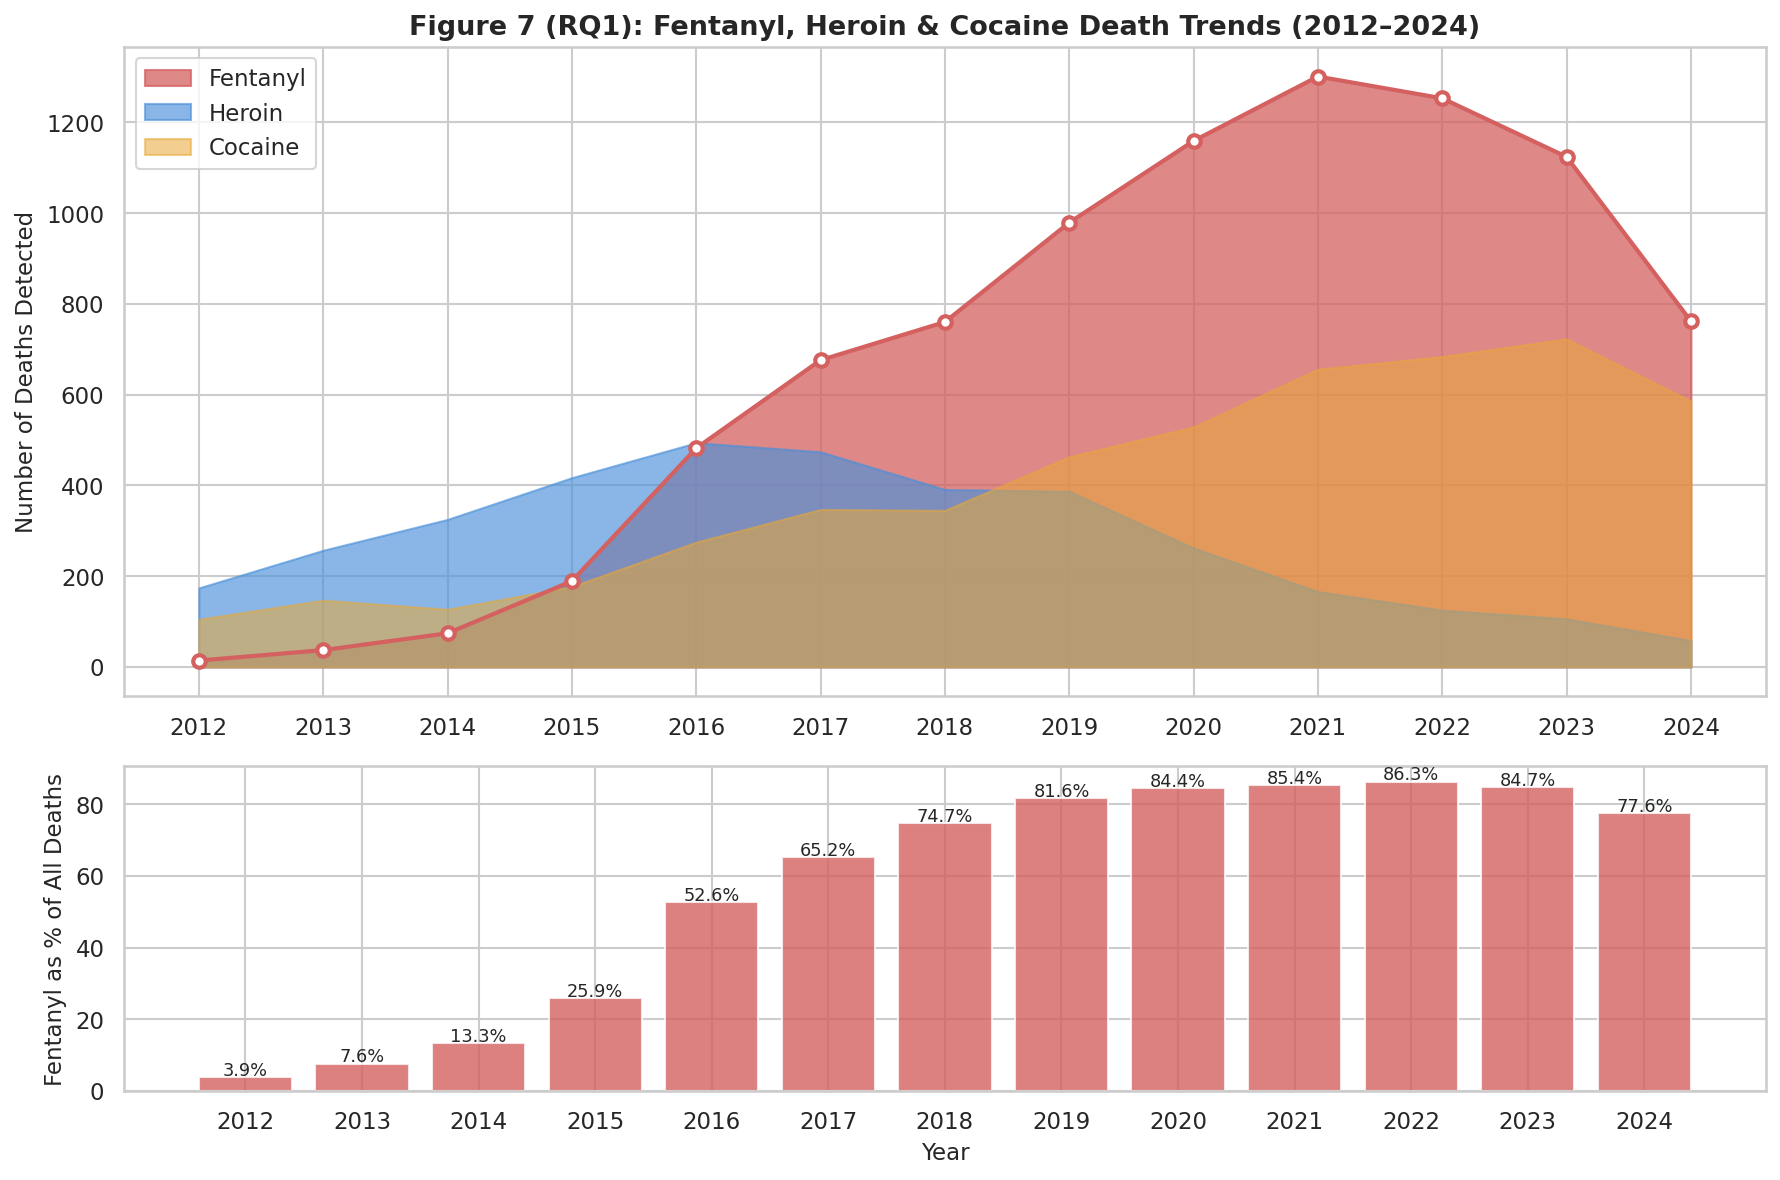


Fentanyl yearly data:
 Year  Total_deaths  Fentanyl_deaths  Fentanyl_pct
 2012           355               14           3.9
 2013           490               37           7.6
 2014           557               74          13.3
 2015           729              189          25.9
 2016           917              482          52.6
 2017          1037              676          65.2
 2018          1017              760          74.7
 2019          1200              979          81.6
 2020          1374             1159          84.4
 2021          1524             1301          85.4
 2022          1452             1253          86.3
 2023          1327             1124          84.7
 2024           982              762          77.6


In [42]:
fentanyl_yearly = df.groupby('Year').agg(
    Total_deaths    = ('Age', 'count'),
    Fentanyl_deaths = ('Fentanyl_flag', 'sum'),
    Heroin_deaths   = ('Heroin_flag', 'sum'),
    Cocaine_deaths  = ('Cocaine_flag', 'sum'),
).reset_index()
fentanyl_yearly['Fentanyl_pct'] = (fentanyl_yearly['Fentanyl_deaths'] /
                                    fentanyl_yearly['Total_deaths'] * 100).round(1)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [2, 1]})

# Top: Stacked area chart
axes[0].fill_between(fentanyl_yearly['Year'], fentanyl_yearly['Fentanyl_deaths'],
                     alpha=0.75, color='#D46060', label='Fentanyl')
axes[0].fill_between(fentanyl_yearly['Year'], fentanyl_yearly['Heroin_deaths'],
                     alpha=0.65, color='#4A90D9', label='Heroin')
axes[0].fill_between(fentanyl_yearly['Year'], fentanyl_yearly['Cocaine_deaths'],
                     alpha=0.55, color='#E8A838', label='Cocaine')

axes[0].plot(fentanyl_yearly['Year'], fentanyl_yearly['Fentanyl_deaths'],
             'o-', color='#D46060', linewidth=2, markersize=6,
             markerfacecolor='white', markeredgewidth=2)

axes[0].set_ylabel('Number of Deaths Detected')
axes[0].set_title('Figure 7 (RQ1): Fentanyl, Heroin & Cocaine Death Trends (2012–2024)')
axes[0].legend()
axes[0].set_xticks(fentanyl_yearly['Year'])

# Bottom: Fentanyl as % of total
axes[1].bar(fentanyl_yearly['Year'], fentanyl_yearly['Fentanyl_pct'],
            color='#D46060', alpha=0.8, edgecolor='white')
for _, row in fentanyl_yearly.iterrows():
    axes[1].text(row['Year'], row['Fentanyl_pct'] + 0.5,
                 f"{row['Fentanyl_pct']}%", ha='center', fontsize=8.5)
axes[1].set_ylabel('Fentanyl as % of All Deaths')
axes[1].set_xlabel('Year')
axes[1].set_xticks(fentanyl_yearly['Year'])

plt.tight_layout()
plt.savefig('fig7_rq1_fentanyl_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFentanyl yearly data:')
print(fentanyl_yearly[['Year','Total_deaths','Fentanyl_deaths','Fentanyl_pct']].to_string(index=False))

### 3.4 – RQ2: Age Distribution by Substance Group

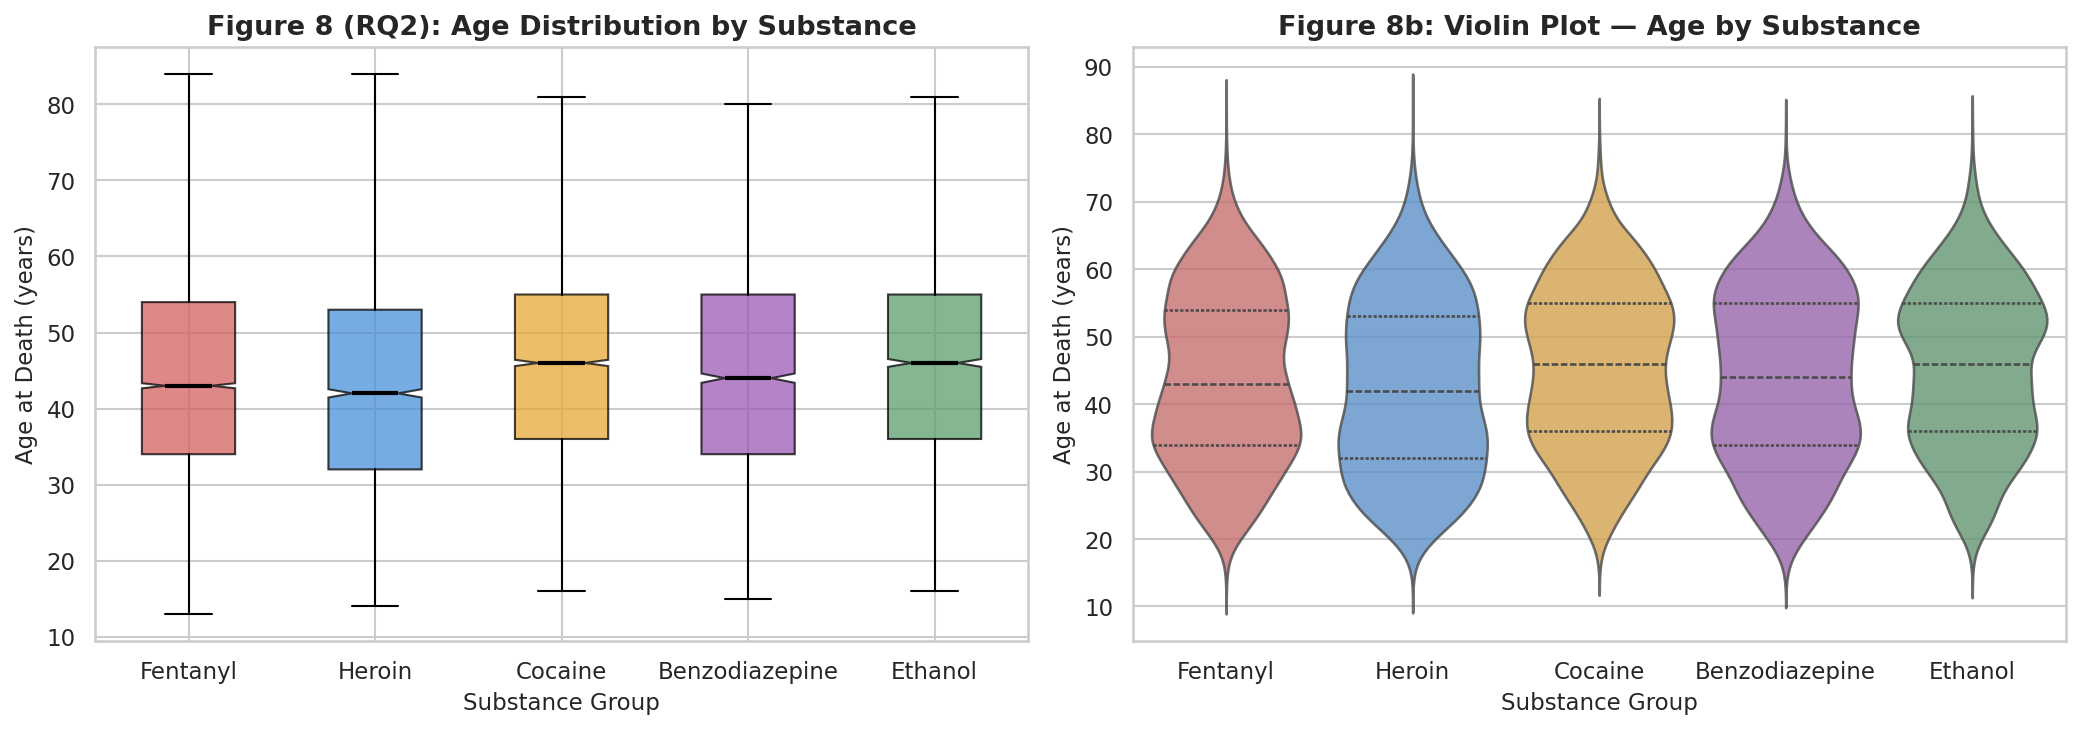

Mean age by substance group:
  Fentanyl             — Mean: 43.9  |  Median: 43  |  Std: 12.6  |  n=8,810
  Heroin               — Mean: 42.5  |  Median: 42  |  Std: 12.8  |  n=3,636
  Cocaine              — Mean: 45.5  |  Median: 46  |  Std: 12.0  |  n=5,164
  Benzodiazepine       — Mean: 44.4  |  Median: 44  |  Std: 12.8  |  n=2,910
  Ethanol              — Mean: 45.4  |  Median: 46  |  Std: 12.0  |  n=3,332


In [43]:
TOP_SUBSTANCES = ['Fentanyl', 'Heroin', 'Cocaine', 'Benzodiazepine', 'Ethanol']

age_groups = {}
for sub in TOP_SUBSTANCES:
    flag = sub + '_flag'
    if flag in df.columns:
        ages = df.loc[df[flag] == 1, 'Age'].dropna()
        age_groups[sub] = ages

# --- Box plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

box_data  = [age_groups[s].values for s in TOP_SUBSTANCES]
box_plot  = axes[0].boxplot(box_data, labels=TOP_SUBSTANCES, patch_artist=True,
                             notch=True, vert=True,
                             medianprops=dict(color='black', linewidth=2))
palette = ['#D46060', '#4A90D9', '#E8A838', '#9B59B6', '#5B9E6E']
for patch, color in zip(box_plot['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

axes[0].set_ylabel('Age at Death (years)')
axes[0].set_xlabel('Substance Group')
axes[0].set_title('Figure 8 (RQ2): Age Distribution by Substance')

# --- Violin plot
plot_df = pd.DataFrame({
    'Age': np.concatenate(box_data),
    'Substance': np.concatenate([[s]*len(age_groups[s]) for s in TOP_SUBSTANCES])
})
sns.violinplot(data=plot_df, x='Substance', y='Age', palette=palette,
               inner='quartile', ax=axes[1], alpha=0.8)
axes[1].set_title('Figure 8b: Violin Plot — Age by Substance')
axes[1].set_ylabel('Age at Death (years)')
axes[1].set_xlabel('Substance Group')

plt.tight_layout()
plt.savefig('fig8_rq2_age_by_substance.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats per group
print('Mean age by substance group:')
for sub, ages in age_groups.items():
    print(f'  {sub:20s} — Mean: {ages.mean():.1f}  |  Median: {ages.median():.0f}  |  Std: {ages.std():.1f}  |  n={len(ages):,}')

### 3.5 – RQ3: Sex-Based Polydrug Death Analysis

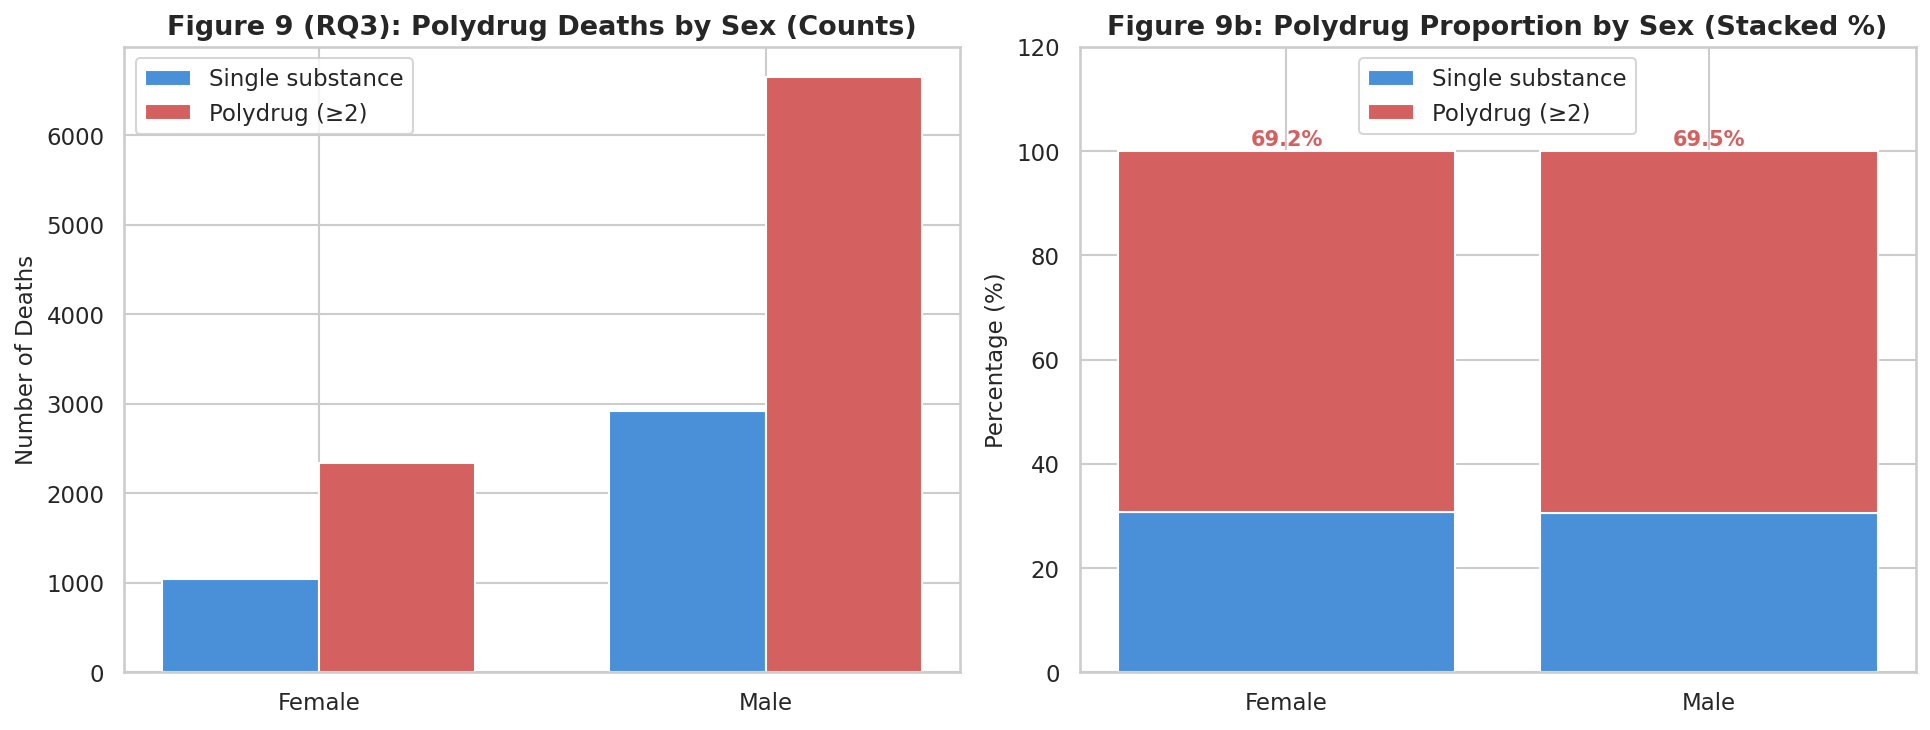


Polydrug breakdown by sex:
Sex_clean            Label  Count  Percent
   Female Single substance   1040     30.8
   Female    Polydrug (≥2)   2340     69.2
     Male Single substance   2915     30.5
     Male    Polydrug (≥2)   6655     69.5


In [44]:
sex_poly = df[df['Sex_clean'].isin(['Male', 'Female'])].copy()

# Count by sex and polydrug status
poly_sex = (sex_poly.groupby(['Sex_clean', 'Is_polydrug'])
            .size().reset_index(name='Count'))
poly_sex['Label'] = poly_sex['Is_polydrug'].map({0: 'Single substance', 1: 'Polydrug (≥2)'})

# Percentage within each sex
totals = sex_poly.groupby('Sex_clean').size()
poly_sex['Percent'] = poly_sex.apply(
    lambda r: r['Count'] / totals[r['Sex_clean']] * 100, axis=1
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grouped bar — absolute counts
poly_pivot = poly_sex.pivot(index='Sex_clean', columns='Label', values='Count').fillna(0)
x = np.arange(len(poly_pivot.index))
width = 0.35
axes[0].bar(x - width/2, poly_pivot['Single substance'], width,
            label='Single substance', color='#4A90D9', edgecolor='white')
axes[0].bar(x + width/2, poly_pivot['Polydrug (≥2)'], width,
            label='Polydrug (≥2)', color='#D46060', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(poly_pivot.index)
axes[0].set_ylabel('Number of Deaths')
axes[0].set_title('Figure 9 (RQ3): Polydrug Deaths by Sex (Counts)')
axes[0].legend()

# Stacked 100% bar — proportions
pct_pivot = poly_sex.pivot(index='Sex_clean', columns='Label', values='Percent').fillna(0)
axes[1].bar(pct_pivot.index, pct_pivot['Single substance'],
            label='Single substance', color='#4A90D9', edgecolor='white')
axes[1].bar(pct_pivot.index, pct_pivot['Polydrug (≥2)'],
            bottom=pct_pivot['Single substance'],
            label='Polydrug (≥2)', color='#D46060', edgecolor='white')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Figure 9b: Polydrug Proportion by Sex (Stacked %)')
axes[1].legend()
axes[1].set_ylim(0, 120)

# Labels on stacked bars
for sex in pct_pivot.index:
    pct_poly = pct_pivot.loc[sex, 'Polydrug (≥2)']
    pct_sing = pct_pivot.loc[sex, 'Single substance']
    axes[1].text(sex, pct_sing + pct_poly + 1, f'{pct_poly:.1f}%',
                 ha='center', fontsize=10, fontweight='bold', color='#D46060')

plt.tight_layout()
plt.savefig('fig9_rq3_polydrug_sex.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPolydrug breakdown by sex:')
print(poly_sex[['Sex_clean','Label','Count','Percent']].to_string(index=False))

### 3.6 – RQ4: Top 10 Death Locations/Cities

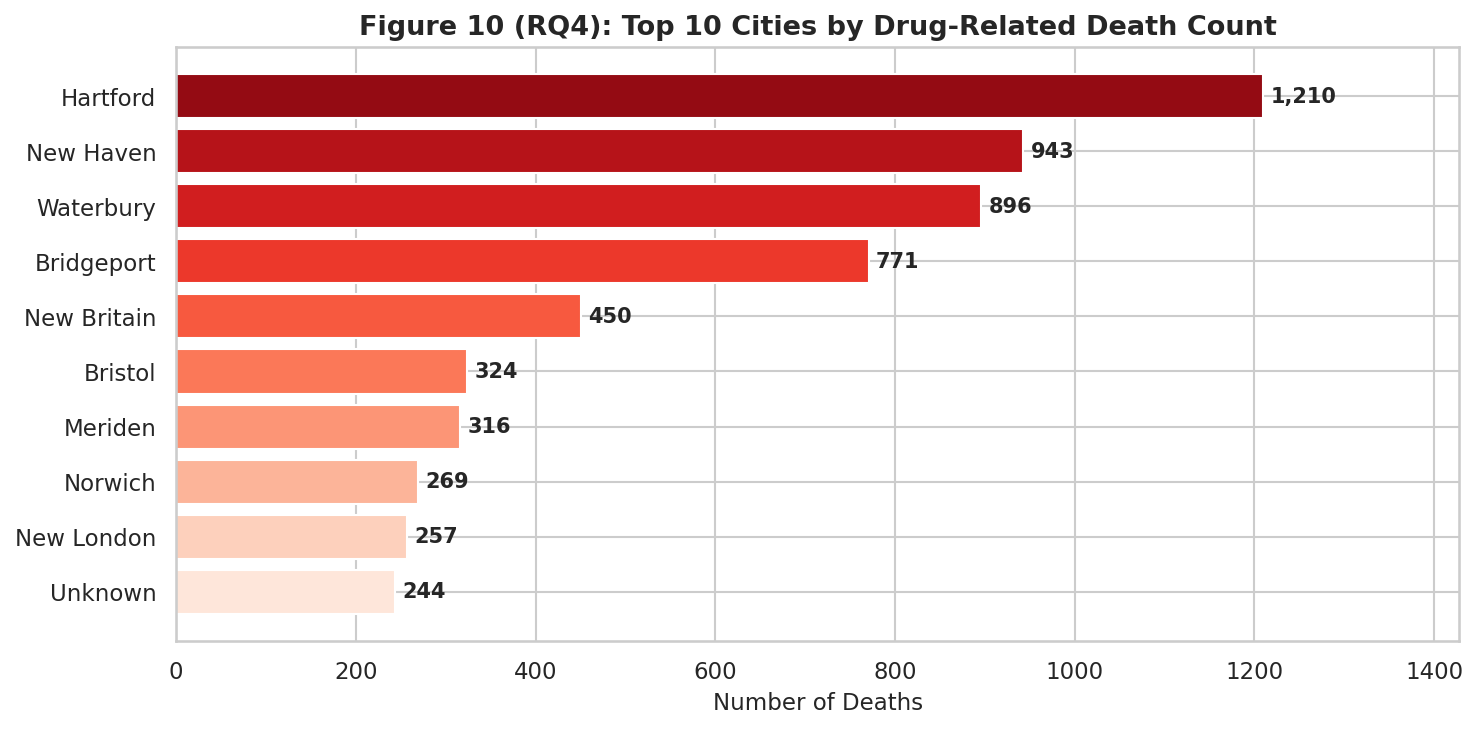


Top 10 cities:
  Hartford             1,210
  New Haven              943
  Waterbury              896
  Bridgeport             771
  New Britain            450
  Bristol                324
  Meriden                316
  Norwich                269
  New London             257
  Unknown                244


In [45]:
# Use Injury City as it has the least nulls and most accurate location
city_counts = df['Injury City'].str.strip().str.title().value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
colors_city = sns.color_palette('Reds_r', len(city_counts))
bars = ax.barh(city_counts.index[::-1], city_counts.values[::-1],
               color=colors_city[::-1], edgecolor='white')
ax.set_xlabel('Number of Deaths')
ax.set_title('Figure 10 (RQ4): Top 10 Cities by Drug-Related Death Count')
for bar, val in zip(bars, city_counts.values[::-1]):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0, city_counts.max() * 1.18)
plt.tight_layout()
plt.savefig('fig10_rq4_top_cities.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 cities:')
for city, count in city_counts.items():
    print(f'  {city:20s} {count:5,}')

### 3.7 Substance Co-Occurrence Heatmap

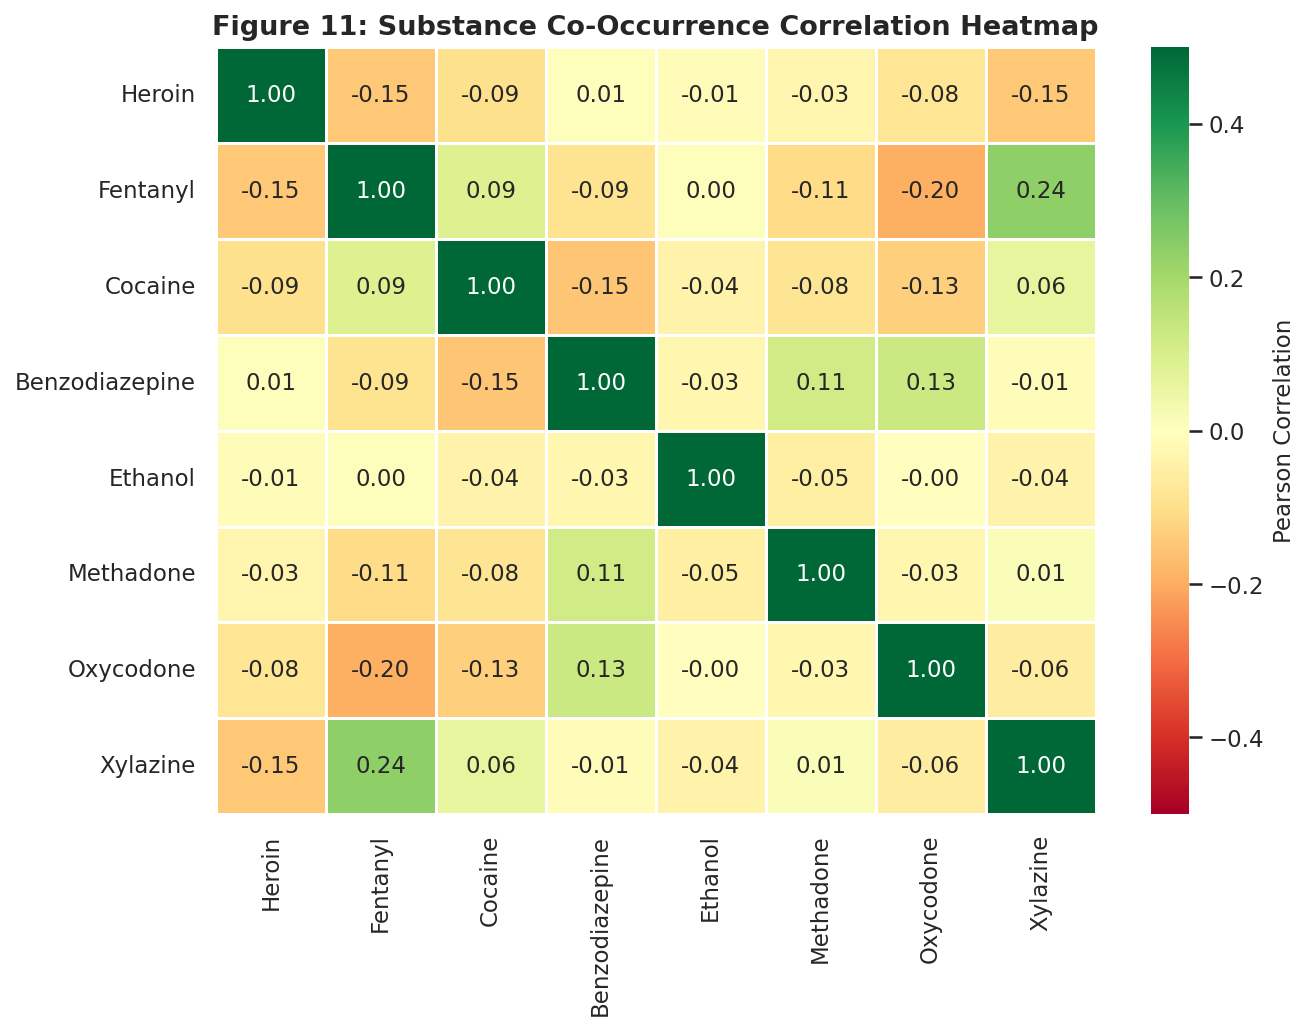

Positive values → substances tend to co-occur.
Negative values → substances tend not to co-occur in the same death.


In [46]:
focus_substances = ['Heroin', 'Fentanyl', 'Cocaine', 'Benzodiazepine',
                    'Ethanol', 'Methadone', 'Oxycodone', 'Xylazine']
focus_flags = [s + '_flag' for s in focus_substances if s + '_flag' in df.columns]

corr_matrix = df[focus_flags].corr()
corr_matrix.index   = [c.replace('_flag', '') for c in corr_matrix.index]
corr_matrix.columns = [c.replace('_flag', '') for c in corr_matrix.columns]

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-0.5, vmax=0.5, linewidths=0.5, linecolor='white',
            ax=ax, cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Figure 11: Substance Co-Occurrence Correlation Heatmap')
plt.tight_layout()
plt.savefig('fig11_substance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Positive values → substances tend to co-occur.')
print('Negative values → substances tend not to co-occur in the same death.')

### 3.8 – Hypothesis Testing: One-Way ANOVA

In [47]:
from scipy.stats import f_oneway, levene, shapiro

print('═══════════════════════════════════════════════════════════════════')
print('  STATISTICAL SIGNIFICANCE TESTING — ONE-WAY ANOVA')
print('  Research Question 2: Does mean age differ across substance groups?')
print('═══════════════════════════════════════════════════════════════════\n')

# Assemble age vectors per substance
groups = {sub: age_groups[sub].values for sub in TOP_SUBSTANCES}

print('Group sizes and descriptive stats:')
print(f'  {"Substance":<20} {"n":>6}  {"Mean":>7}  {"SD":>7}')
print('  ' + '-'*44)
for sub, vals in groups.items():
    print(f'  {sub:<20} {len(vals):>6,}  {vals.mean():>7.2f}  {vals.std():>7.2f}')

print()

# ── ANOVA ───────────────────────────────────────────────────────────────────
f_stat, p_value = f_oneway(*groups.values())

print(f'  ANOVA F-statistic : {f_stat:.4f}')
print(f'  ANOVA p-value     : {p_value:.6e}')
print()

ALPHA = 0.05
if p_value < ALPHA:
    decision = 'REJECT'
    conclusion = (f'There is statistically significant evidence that the mean age at death '
                  f'differs across substance groups (F = {f_stat:.2f}, p = {p_value:.2e}, α = {ALPHA}).\n'
                  f'  → H₀ is REJECTED. H₁ is supported.')
else:
    decision = 'FAIL TO REJECT'
    conclusion = (f'There is insufficient evidence to conclude that mean age differs across '
                  f'substance groups (F = {f_stat:.2f}, p = {p_value:.2e}, α = {ALPHA}).\n'
                  f'  → H₀ cannot be rejected.')

print(f'  Decision (α = {ALPHA}): {decision} H₀')
print()
print(f'  Conclusion: {conclusion}')
print()
print('═══════════════════════════════════════════════════════════════════')

═══════════════════════════════════════════════════════════════════
  STATISTICAL SIGNIFICANCE TESTING — ONE-WAY ANOVA
  Research Question 2: Does mean age differ across substance groups?
═══════════════════════════════════════════════════════════════════

Group sizes and descriptive stats:
  Substance                 n     Mean       SD
  --------------------------------------------
  Fentanyl              8,810    43.87    12.61
  Heroin                3,636    42.54    12.76
  Cocaine               5,164    45.46    11.98
  Benzodiazepine        2,910    44.37    12.77
  Ethanol               3,332    45.41    11.95

  ANOVA F-statistic : 38.6561
  ANOVA p-value     : 2.649760e-32

  Decision (α = 0.05): REJECT H₀

  Conclusion: There is statistically significant evidence that the mean age at death differs across substance groups (F = 38.66, p = 2.65e-32, α = 0.05).
  → H₀ is REJECTED. H₁ is supported.

═══════════════════════════════════════════════════════════════════


In [48]:
# ── Levene's Test for Homogeneity of Variance (ANOVA assumption check) ───────
lev_stat, lev_p = levene(*groups.values())
print(f"Levene's test (variance equality): W = {lev_stat:.3f}, p = {lev_p:.4f}")
if lev_p < 0.05:
    print("  → Variances are NOT equal across groups (p < 0.05).")
    print("     Note: ANOVA is robust to this violation with large samples (n > 30 per group).")
else:
    print("  → Variances are approximately equal. ANOVA assumption satisfied.")

Levene's test (variance equality): W = 13.953, p = 0.0000
  → Variances are NOT equal across groups (p < 0.05).
     Note: ANOVA is robust to this violation with large samples (n > 30 per group).


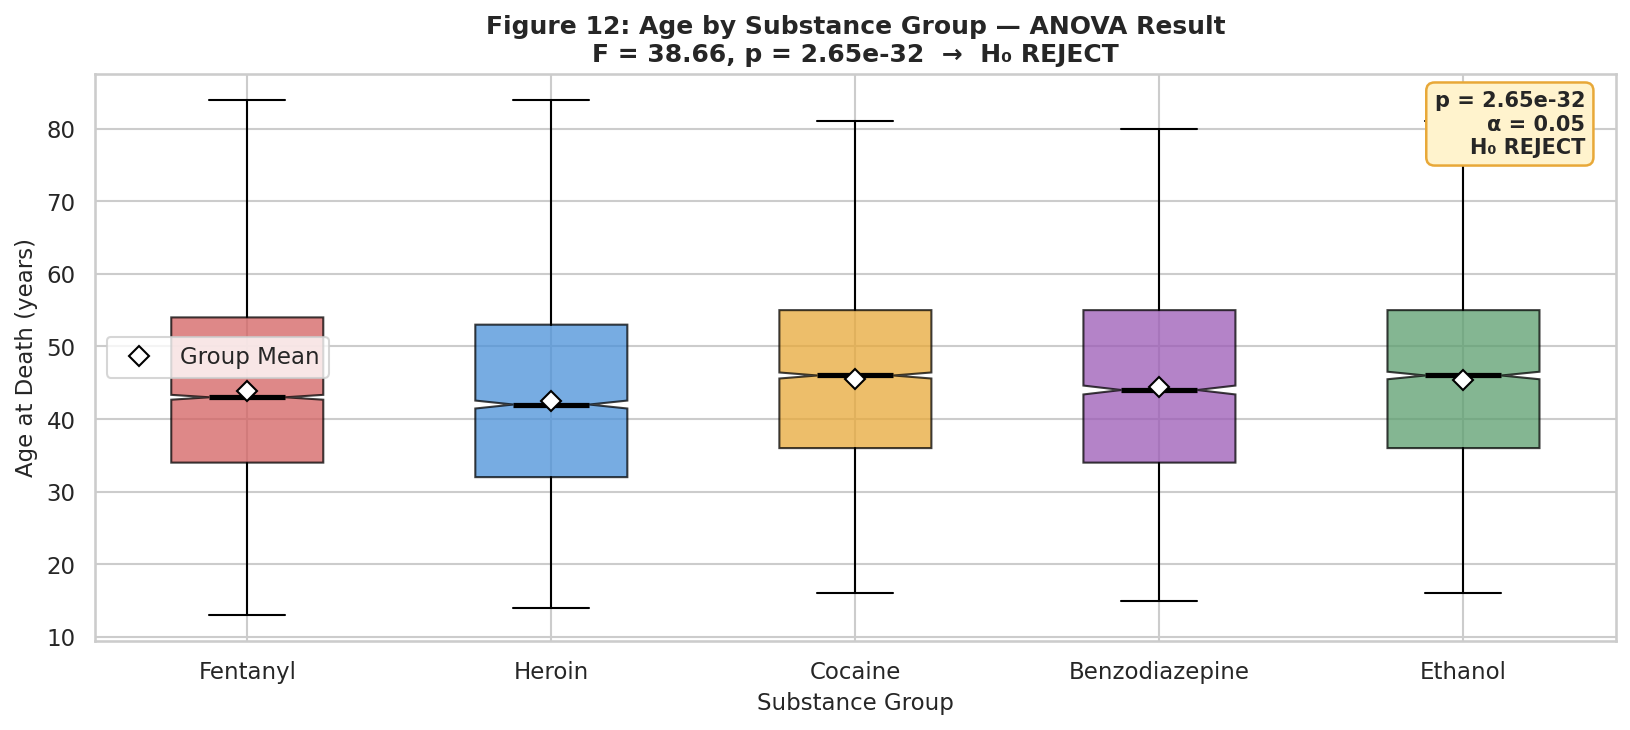

In [49]:
# ── Visualise ANOVA result ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

bp = ax.boxplot([groups[s] for s in TOP_SUBSTANCES],
                labels=TOP_SUBSTANCES,
                patch_artist=True, notch=True,
                medianprops=dict(color='black', linewidth=2.5),
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Add mean markers
for i, sub in enumerate(TOP_SUBSTANCES, start=1):
    ax.plot(i, groups[sub].mean(), 'D', color='white',
            markeredgecolor='black', markersize=7, zorder=5)

ax.set_ylabel('Age at Death (years)')
ax.set_xlabel('Substance Group')
ax.set_title(
    f'Figure 12: Age by Substance Group — ANOVA Result\n'
    f'F = {f_stat:.2f}, p = {p_value:.2e}  →  H₀ {decision}',
    fontsize=12
)
ax.text(0.98, 0.97,
        f'p = {p_value:.2e}\nα = {ALPHA}\nH₀ {decision}',
        transform=ax.transAxes, va='top', ha='right',
        fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF3CD',
                  edgecolor='#E8A838', linewidth=1.2))
# Diamond = mean legend
from matplotlib.lines import Line2D
legend_elem = Line2D([0], [0], marker='D', color='w', markerfacecolor='white',
                     markeredgecolor='black', markersize=7, label='Group Mean')
ax.legend(handles=[legend_elem])

plt.tight_layout()
plt.savefig('fig12_anova_result.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.9 – Chi-Squared Test: Sex vs Polydrug Deaths (RQ3)

In [53]:
from scipy.stats import chi2_contingency

print('═══════════════════════════════════════════════════════════════════')
print('  CHI-SQUARED TEST — Sex vs Polydrug Deaths (RQ3)')
print('═══════════════════════════════════════════════════════════════════\n')

contingency = pd.crosstab(
    sex_poly['Sex_clean'],
    sex_poly['Is_polydrug'],
    margins=True
)
contingency.columns = ['Single substance', 'Polydrug (≥2)', 'Total']
print('Contingency table:')
print(contingency.to_string())
print()

ct = pd.crosstab(sex_poly['Sex_clean'], sex_poly['Is_polydrug'])
chi2, p_chi, dof, expected = chi2_contingency(ct)

print(f'  Chi-squared (χ²) : {chi2:.4f}')
print(f'  Degrees of freedom: {dof}')
print(f'  p-value           : {p_chi:.6e}')
print()

if p_chi < 0.05:
    print(f'  → STATISTICALLY SIGNIFICANT (p < 0.05)')
    print(f'     Sex and polydrug death rate are NOT independent.')
    print(f'     There IS a significant sex-based difference in polydrug mortality.')
else:
    print(f'  → NOT STATISTICALLY SIGNIFICANT (p ≥ 0.05)')
    print(f'     No significant sex-based difference detected.')
print()



═══════════════════════════════════════════════════════════════════
  CHI-SQUARED TEST — Sex vs Polydrug Deaths (RQ3)
═══════════════════════════════════════════════════════════════════

Contingency table:
           Single substance  Polydrug (≥2)  Total
Sex_clean                                        
Female                 1040           2340   3380
Male                   2915           6655   9570
All                    3955           8995  12950

  Chi-squared (χ²) : 0.0986
  Degrees of freedom: 1
  p-value           : 7.534612e-01

  → NOT STATISTICALLY SIGNIFICANT (p ≥ 0.05)
     No significant sex-based difference detected.



### 3.10 – Summary Figure: All Key Metrics at a Glance

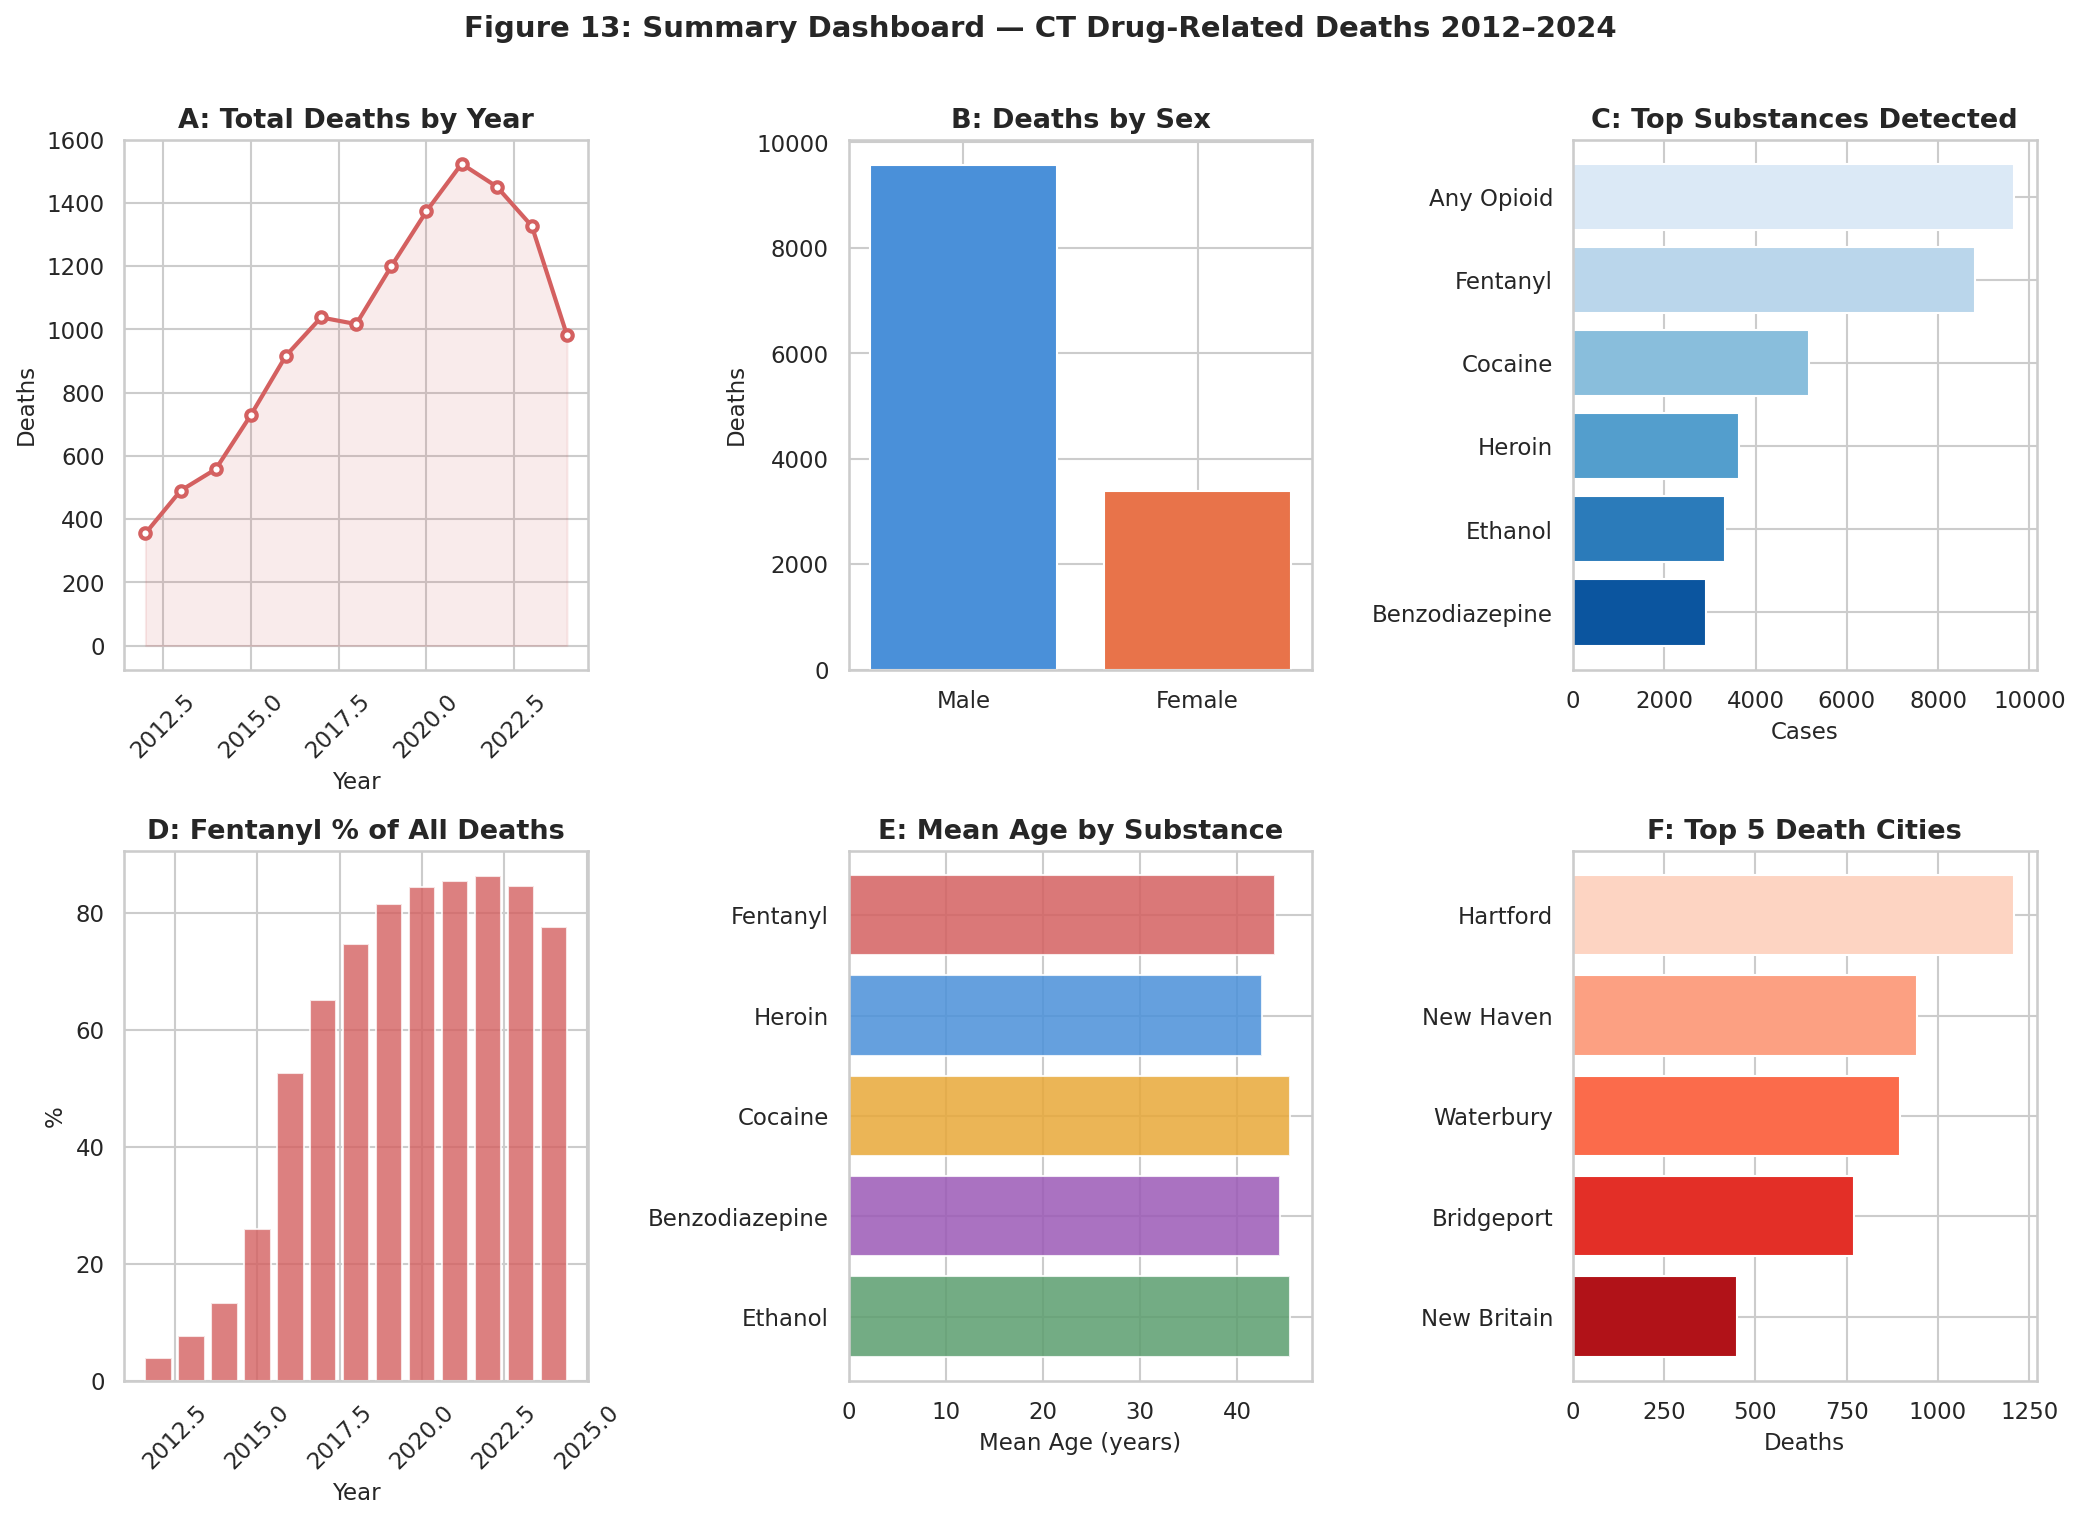

In [52]:
fig = plt.figure(figsize=(14, 10))
fig.suptitle('Figure 13: Summary Dashboard — CT Drug-Related Deaths 2012–2024',
             fontsize=14, fontweight='bold', y=1.01)

# ── Panel A: Yearly trend ────────────────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(yearly['Year'], yearly['Deaths'], 'o-', color='#D46060',
         linewidth=2, markersize=5, markerfacecolor='white', markeredgewidth=2)
ax1.fill_between(yearly['Year'], yearly['Deaths'], alpha=0.12, color='#D46060')
ax1.set_title('A: Total Deaths by Year')
ax1.set_xlabel('Year'); ax1.set_ylabel('Deaths')
ax1.tick_params(axis='x', rotation=45)

# ── Panel B: Sex breakdown ───────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
ax2.bar(sex_counts.index, sex_counts.values,
        color=['#4A90D9', '#E8734A'], edgecolor='white')
ax2.set_title('B: Deaths by Sex')
ax2.set_ylabel('Deaths')

# ── Panel C: Substance frequency ─────────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
top_subs = substance_sums.head(6)
ax3.barh(top_subs.index[::-1], top_subs.values[::-1],
         color=sns.color_palette('Blues_r', 6), edgecolor='white')
ax3.set_title('C: Top Substances Detected')
ax3.set_xlabel('Cases')

# ── Panel D: Fentanyl % trend ─────────────────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
ax4.bar(fentanyl_yearly['Year'], fentanyl_yearly['Fentanyl_pct'],
        color='#D46060', alpha=0.8, edgecolor='white')
ax4.set_title('D: Fentanyl % of All Deaths')
ax4.set_xlabel('Year'); ax4.set_ylabel('%')
ax4.tick_params(axis='x', rotation=45)

# ── Panel E: Age by substance (means) ────────────────────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
means = {s: groups[s].mean() for s in TOP_SUBSTANCES}
ax5.barh(list(means.keys())[::-1], list(means.values())[::-1],
         color=palette[::-1], edgecolor='white', alpha=0.85)
ax5.set_title('E: Mean Age by Substance')
ax5.set_xlabel('Mean Age (years)')

# ── Panel F: Top 5 cities ─────────────────────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
top5_cities = city_counts.head(5)
ax6.barh(top5_cities.index[::-1], top5_cities.values[::-1],
         color=sns.color_palette('Reds_r', 5), edgecolor='white')
ax6.set_title('F: Top 5 Death Cities')
ax6.set_xlabel('Deaths')

plt.tight_layout()
plt.savefig('fig13_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()